In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/divyanshyecho/imerge-2000-2024-daily/imerg_india_025_jjas_2000_2024.nc
/kaggle/input/datasets/divyanshyecho/vorticity-center-2000-2022/lps_daily_2000_2022.parquet
/kaggle/input/datasets/divyanshyecho/era5-uv850-mean/wind_daily_uv850.nc
/kaggle/input/datasets/divyanshyecho/era5-uv850-mean/wind_daily_uv800.nc
/kaggle/input/datasets/divyanshyecho/era5-uv850-mean/wind_daily_uv700.nc
/kaggle/input/datasets/divyanshyecho/era5-uv850-mean/wind_daily_uv750.nc
/kaggle/input/datasets/divyanshyecho/etopo-india-dem/etopo_india_60s.nc


In [2]:
import glob, os
print("attached files under /kaggle/input:\n")
for f in sorted(glob.glob('/kaggle/input/**/*', recursive=True)):
    if os.path.isfile(f) and f.lower().endswith(('.nc','.parquet','.csv','.txt','.dat')):
        print(f"  {os.path.getsize(f)/1e6:8.1f} MB  {f}")
find = lambda keys: [f for f in glob.glob('/kaggle/input/**/*', recursive=True)
                     if os.path.isfile(f) and any(k in f.lower() for k in keys)]
print("\nIMERG:", find(['imerg'])[:1], "\nWIND :", find(['wind','uv850'])[:1],
      "\nDEM  :", find(['etopo','topo','elev','dem'])[:1], "\nLPS  :", find(['vortic','lps','center'])[:1])

attached files under /kaggle/input:

    1107.9 MB  /kaggle/input/datasets/divyanshyecho/era5-uv850-mean/wind_daily_uv700.nc
    1107.9 MB  /kaggle/input/datasets/divyanshyecho/era5-uv850-mean/wind_daily_uv750.nc
    1107.9 MB  /kaggle/input/datasets/divyanshyecho/era5-uv850-mean/wind_daily_uv800.nc
    2038.4 MB  /kaggle/input/datasets/divyanshyecho/era5-uv850-mean/wind_daily_uv850.nc
      12.2 MB  /kaggle/input/datasets/divyanshyecho/etopo-india-dem/etopo_india_60s.nc
     225.0 MB  /kaggle/input/datasets/divyanshyecho/imerge-2000-2024-daily/imerg_india_025_jjas_2000_2024.nc
       0.1 MB  /kaggle/input/datasets/divyanshyecho/vorticity-center-2000-2022/lps_daily_2000_2022.parquet

IMERG: ['/kaggle/input/datasets/divyanshyecho/imerge-2000-2024-daily/imerg_india_025_jjas_2000_2024.nc'] 
WIND : ['/kaggle/input/datasets/divyanshyecho/era5-uv850-mean/wind_daily_uv850.nc'] 
DEM  : ['/kaggle/input/datasets/divyanshyecho/etopo-india-dem/etopo_india_60s.nc'] 
LPS  : ['/kaggle/input/datasets/

In [3]:
# ── IMERG SETUP : load + mask + threshold + 8-connectivity labeling (run FIRST) ──
# Mirrors the ERA5 check-6 SETUP, with the IMERG-specific changes:
#   • single file; coords are 'lat'/'lon' (NOT 'latitude'/'longitude')
#   • var 'tp' already in mm/day
#   • per-grid p99 thresholds RECOMPUTED on IMERG (★ do NOT reuse ERA5's)
# Variable names (data_precip, lat, lon, times_pd, india_mask, Label8, NE8_raw)
# are kept identical so the canonical run_tracking_mean() cell runs unchanged.
import numpy as np, pandas as pd, xarray as xr, glob, subprocess, warnings
from scipy import ndimage
warnings.filterwarnings("ignore")

subprocess.run(['pip', 'install', 'regionmask', '--quiet'], check=True)
import regionmask

# --- load IMERG (single file; coords lat/lon; tp in mm/day) ---
IMERG_PATH = '/kaggle/input/datasets/divyanshyecho/imerge-2000-2024-daily/imerg_india_025_jjas_2000_2024.nc'
if not glob.glob(IMERG_PATH):                       # fallback if the path moved
    cand = [f for f in glob.glob('/kaggle/input/**/*.nc', recursive=True) if 'imerg' in f.lower()]
    assert cand, "IMERG .nc not found under /kaggle/input"
    IMERG_PATH = cand[0]
print("IMERG file:", IMERG_PATH)

ds = xr.open_dataset(IMERG_PATH)
data_precip = ds['tp'].values.astype('float32')          # (3050,141,161) mm/day
lat  = ds['lat'].values.astype('float32')                # 40 -> 5  (descending)
lon  = ds['lon'].values.astype('float32')                # 60 -> 100
times_pd = pd.to_datetime(ds['time'].values)
ds.close()
print(f"shape : {data_precip.shape}   time : {str(times_pd[0])[:10]} -> {str(times_pd[-1])[:10]}")
print(f"lat {lat[0]}->{lat[-1]} ({len(lat)})  lon {lon[0]}->{lon[-1]} ({len(lon)})")
print(f"NaN frac {np.isnan(data_precip).mean():.4f} | neg {(data_precip<0).sum()} | "
      f"min/mean/max {np.nanmin(data_precip):.2f}/{np.nanmean(data_precip):.2f}/{np.nanmax(data_precip):.0f}")

# --- Section 1 : India mask + per-grid threshold (RECOMPUTED on IMERG) ---
RAINY_DAY_MIN, PERCENTILE, FLOOR_MM = 1.0, 99.0, 50.0
countries  = regionmask.defined_regions.natural_earth_v5_0_0.countries_110
india_mask = (countries.mask(lon, lat).values == 98)
print(f"India cells : {india_mask.sum()} / {len(lat)*len(lon)}")

data_masked = np.where((data_precip > RAINY_DAY_MIN) & india_mask[np.newaxis, :, :],
                       data_precip, np.nan).astype('float32')
jjas_mask   = (times_pd.month >= 6) & (times_pd.month <= 9)     # all True (cube is JJAS-only)
per_grid_99 = np.nanpercentile(data_masked[jjas_mask, :, :], PERCENTILE, axis=0).astype('float32')
per_grid_threshold = np.maximum(per_grid_99, FLOOR_MM).astype('float32')
per_grid_threshold[~india_mask] = 999.0       # sentinel blocking non-India cells (same as ERA5)

data_precip_safe = np.where(np.isnan(data_precip), 0.0, data_precip).astype('float32')
threshold_3d = np.broadcast_to(per_grid_threshold[np.newaxis, :, :], data_precip.shape).copy()
c = (data_precip_safe > threshold_3d)
print(f"exceedance rate : {c.mean()*100:.3f}%")

# --- threshold sanity (expect HIGHER than ERA5: IMERG resolves heavier convective cores) ---
thr_in = per_grid_threshold[india_mask]
print(f"threshold (India) min/median/max = {thr_in.min():.1f} / "
      f"{np.median(thr_in):.1f} / {thr_in.max():.1f} mm/day")
print(f"India cells pinned to the {FLOOR_MM:.0f} mm floor : "
      f"{(per_grid_99[india_mask] < FLOOR_MM).mean()*100:.1f}%")
leak = int((c & ~india_mask[np.newaxis, :, :]).sum())
print(f"non-India exceedance cells (born+killed by domain_exit, India results unaffected): {leak}")

# --- Section 2 : 8-connectivity labeling ---
struct8 = ndimage.generate_binary_structure(2, 2)
n_days, n_lat, n_lon = data_precip.shape
Label8  = np.zeros((n_days, n_lat, n_lon), dtype='int32')
NE8_raw = np.zeros(n_days, dtype='int32')
for k in range(n_days):
    lab, nr = ndimage.label(c[k].astype('int8'), structure=struct8)
    Label8[k] = lab; NE8_raw[k] = nr
print(f"mean NE = {NE8_raw.mean():.3f} objects/day   labeling done ✓")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 3.9 MB/s eta 0:00:00
IMERG file: /kaggle/input/datasets/divyanshyecho/imerge-2000-2024-daily/imerg_india_025_jjas_2000_2024.nc
shape : (3050, 141, 161)   time : 2000-06-01 -> 2024-09-30
lat 40.0->5.0 (141)  lon 60.0->100.0 (161)
NaN frac 0.0000 | neg 0 | min/mean/max 0.00/5.59/1132
India cells : 4452 / 22701
exceedance rate : 0.107%
threshold (India) min/median/max = 50.0 / 71.8 / 199.8 mm/day
India cells pinned to the 50 mm floor : 14.2%
non-India exceedance cells (born+killed by domain_exit, India results unaffected): 8
mean NE = 3.566 objects/day   labeling done ✓


In [4]:
# ── MEAN tracker, NO fallback — canonical run_tracking_mean (run AFTER SETUP) ──
# Needs Label8, NE8_raw, india_mask, lat, lon, times_pd, data_precip (from SETUP).
import numpy as np, pandas as pd

OVERLAP_THRESH, MIN_TRACK_CELLS, DOMAIN_EXIT_FRAC = 0.10, 1, 0.50
n_days, n_lat, n_lon = data_precip.shape

def run_tracking_mean():
    track_stats_rows, merge_event_rows, split_event_rows = [], [], []
    active_tracks, births_per_date = {}, {}
    counters = {'track': 0, 'merge': 0, 'split': 0}

    def jjas_day_num(ts): return int((ts - pd.Timestamp(f"{ts.year}-06-01")).days + 1)

    def get_objects(day_idx):
        labeled, n_obj, objs = Label8[day_idx], NE8_raw[day_idx], {}
        for lbl in range(1, n_obj + 1):
            mask = (labeled == lbl); sz = int(mask.sum())
            if sz < MIN_TRACK_CELLS: continue
            r_, c_ = np.where(mask)
            objs[lbl] = {'size': sz,
                         'centroid': (float(lat[r_].mean()), float(lon[c_].mean())),
                         'outside': int((mask & ~india_mask).sum())}
        return objs

    def compute_overlaps(dt, dt1, ot, ot1):
        lab_t, lab_t1, pairs = Label8[dt], Label8[dt1], {}
        for li in ot:
            mi = (lab_t == li)
            for lj in np.unique(lab_t1[mi]):
                if lj == 0 or lj not in ot1: continue
                sh = int((mi & (lab_t1 == lj)).sum())
                if sh == 0: continue
                fwd, bwd = sh / ot[li]['size'], sh / ot1[lj]['size']
                pairs[(li, lj)] = (fwd, bwd, sh, (fwd + bwd) / 2.0)   # MEAN
        return pairs

    def domain_exit(o): return (o['outside'] / o['size']) > DOMAIN_EXIT_FRAC

    def new_track(di, lbl, o, start_type, split_from=-1):
        counters['track'] += 1; tnum, ts = counters['track'], times_pd[di]
        ds = ts.strftime('%Y%m%d')
        births_per_date[ds] = births_per_date.get(ds, 0) + 1
        tid = f"{ds}_{births_per_date[ds]:03d}"; clat, clon = o['centroid']
        row = {'track_num': tnum, 'track_id': tid, 'date': ds, 'year': ts.year,
               'jjas_day': jjas_day_num(ts), 'day_of_track': 0, 'size': o['size'],
               'centroid_lat': round(clat, 3), 'centroid_lon': round(clon, 3),
               'merge_event': False, 'split_event': False, 'link_type': 'birth',
               'link_sh': 0, 'link_score': np.nan,
               'start_type': start_type, 'end_type': None, 'duration': None,
               'split_from_track': split_from, 'merge_into_track': -1, 'day_lbl': lbl}
        active_tracks[tnum] = {'track_id': tid, 'last_day': di, 'last_lbl': lbl,
                               'last_centroid': o['centroid'], 'last_size': o['size'],
                               'start_type': start_type, 'duration': 1,
                               'split_from': split_from, 'daily_rows': [row]}
        return tnum

    def extend_track(tnum, di, lbl, o, merge_event=False, split_event=False,
                     link_type='overlap', link_sh=0, link_score=np.nan):
        tr = active_tracks[tnum]; tr['duration'] += 1; ts = times_pd[di]; clat, clon = o['centroid']
        tr['daily_rows'].append(
            {'track_num': tnum, 'track_id': tr['track_id'], 'date': ts.strftime('%Y%m%d'),
             'year': ts.year, 'jjas_day': jjas_day_num(ts), 'day_of_track': tr['duration'] - 1,
             'size': o['size'], 'centroid_lat': round(clat, 3), 'centroid_lon': round(clon, 3),
             'merge_event': merge_event, 'split_event': split_event, 'link_type': link_type,
             'link_sh': int(link_sh),
             'link_score': (round(float(link_score), 4) if link_score == link_score else np.nan),
             'start_type': tr['start_type'], 'end_type': None, 'duration': None,
             'split_from_track': tr['split_from'], 'merge_into_track': -1, 'day_lbl': lbl})
        tr['last_day'], tr['last_lbl'] = di, lbl
        tr['last_centroid'], tr['last_size'] = o['centroid'], o['size']

    def terminate_track(tnum, end_type, merge_into=-1):
        tr = active_tracks[tnum]; dur = tr['duration']; rows = tr['daily_rows']
        for r in rows: r['duration'] = dur
        rows[-1]['end_type'] = end_type; rows[-1]['merge_into_track'] = merge_into
        track_stats_rows.extend(rows); del active_tracks[tnum]

    for lbl, o in get_objects(0).items():
        tn = new_track(0, lbl, o, 'season_start')
        if domain_exit(o): terminate_track(tn, 'domain_exit')

    for di in range(n_days - 1):
        ts_today, ts_next = times_pd[di], times_pd[di + 1]
        if ts_today.month == 9 and ts_today.day == 30:
            for tn in list(active_tracks): terminate_track(tn, 'season_end')
            for lbl, o in get_objects(di + 1).items():
                tn = new_track(di + 1, lbl, o, 'season_start')
                if domain_exit(o): terminate_track(tn, 'domain_exit')
            continue
        ot, ot1 = get_objects(di), get_objects(di + 1)
        if len(ot1) == 0:
            for tn in list(active_tracks): terminate_track(tn, 'natural_death')
            continue
        if len(ot) == 0:
            for tn in list(active_tracks): terminate_track(tn, 'natural_death')
            for lbl, o in ot1.items():
                tn = new_track(di + 1, lbl, o, 'natural_birth')
                if domain_exit(o): terminate_track(tn, 'domain_exit')
            continue

        pairs = compute_overlaps(di, di + 1, ot, ot1)
        fwd_links, bwd_links = {}, {}
        for (li, lj), (f, b, sh, sc) in pairs.items():
            fwd_links.setdefault(li, []).append((lj, f, b, sh, sc))
            bwd_links.setdefault(lj, []).append((li, f, b, sh, sc))
        lbl_to_track = {tr['last_lbl']: tn for tn, tr in active_tracks.items() if tr['last_day'] == di}
        handled_today, handled_next = set(), set()

        # STEP 1 : MERGES
        mc = []
        for lj in ot1:
            par = [(li, f, b, sh, sc) for (li, f, b, sh, sc) in bwd_links.get(lj, [])
                   if sc >= OVERLAP_THRESH and li in lbl_to_track]
            if len(par) >= 2: mc.append((sum(p[4] for p in par), lj, par))
        mc.sort(key=lambda x: x[0], reverse=True)
        for combined, lj, par in mc:
            if lj in handled_next or any(p[0] in handled_today for p in par): continue
            par = [p for p in par if lbl_to_track.get(p[0]) in active_tracks]
            if len(par) < 2: continue
            par.sort(key=lambda p: ot[p[0]]['size'], reverse=True)
            obj_j = ot1[lj]; dom_li = par[0][0]; dom_tn = lbl_to_track[dom_li]
            absorbed = par[1:]; absorbed_tns = [lbl_to_track[p[0]] for p in absorbed]
            clat_j, clon_j = obj_j['centroid']; counters['merge'] += 1
            merge_event_rows.append(
                {'merge_id': counters['merge'], 'date': ts_next.strftime('%Y%m%d'),
                 'year': ts_next.year, 'jjas_day': jjas_day_num(ts_next), 'dominant_track': dom_tn,
                 'absorbed_tracks': ','.join(str(t) for t in absorbed_tns),
                 'n_absorbed': len(absorbed_tns), 'merged_size_after': obj_j['size'],
                 'centroid_lat': round(clat_j, 3), 'centroid_lon': round(clon_j, 3)})
            extend_track(dom_tn, di + 1, lj, obj_j, merge_event=True, link_type='merge',
                         link_sh=par[0][3], link_score=par[0][4])
            for atn in absorbed_tns: terminate_track(atn, 'merge_death', merge_into=dom_tn)
            for p in par: handled_today.add(p[0])
            handled_next.add(lj)

        # STEP 2 : SPLITS
        for li, obj_i in ot.items():
            if li in handled_today or li not in lbl_to_track: continue
            par_tn = lbl_to_track[li]
            if par_tn not in active_tracks: continue
            ch = [(lj, f, b, sh, sc) for (lj, f, b, sh, sc) in fwd_links.get(li, [])
                  if sc >= OVERLAP_THRESH and lj not in handled_next]
            if len(ch) < 2: continue
            ch.sort(key=lambda c: ot1[c[0]]['size'], reverse=True)
            dom_lj = ch[0][0]; dom_obj = ot1[dom_lj]; others = ch[1:]
            clat_i, clon_i = obj_i['centroid']
            extend_track(par_tn, di + 1, dom_lj, dom_obj, split_event=True, link_type='split',
                         link_sh=ch[0][3], link_score=ch[0][4])
            handled_today.add(li); handled_next.add(dom_lj); child_tns = []
            for co in others:
                ctn = new_track(di + 1, co[0], ot1[co[0]], 'split_birth', split_from=par_tn)
                handled_next.add(co[0]); child_tns.append(ctn)
                if domain_exit(ot1[co[0]]): terminate_track(ctn, 'domain_exit')
            counters['split'] += 1
            split_event_rows.append(
                {'split_id': counters['split'], 'date': ts_next.strftime('%Y%m%d'),
                 'year': ts_next.year, 'jjas_day': jjas_day_num(ts_next),
                 'parent_track': par_tn, 'child_tracks': ','.join(str(t) for t in child_tns),
                 'n_children': len(child_tns), 'parent_size': obj_i['size'],
                 'centroid_lat': round(clat_i, 3), 'centroid_lon': round(clon_i, 3)})

        # STEP 3 : CONTINUATIONS — any non-zero overlap, strongest shared wins
        cc = [(sh, li, lj) for (li, lj), (f, b, sh, sc) in pairs.items()
              if li not in handled_today and lj not in handled_next and li in lbl_to_track]
        cc.sort(key=lambda x: x[0], reverse=True)
        for sh, li, lj in cc:
            if li in handled_today or lj in handled_next: continue
            tn = lbl_to_track.get(li)
            if tn is None or tn not in active_tracks: continue
            obj_j = ot1[lj]
            extend_track(tn, di + 1, lj, obj_j, link_type='overlap',
                         link_sh=sh, link_score=pairs[(li, lj)][3])
            handled_today.add(li); handled_next.add(lj)
            if domain_exit(obj_j): terminate_track(tn, 'domain_exit')

        # STEP 4 : NO FALLBACK — any active track not extended today dies
        for tn in list(active_tracks.keys()):
            tr = active_tracks.get(tn)
            if tr is None or tr['last_day'] != di: continue
            terminate_track(tn, 'natural_death')

        # STEP 5 : BIRTHS
        for lj, obj_j in ot1.items():
            if lj in handled_next: continue
            tn = new_track(di + 1, lj, obj_j, 'natural_birth')
            if domain_exit(obj_j): terminate_track(tn, 'domain_exit')

    for tn in list(active_tracks): terminate_track(tn, 'season_end')

    df_stats = pd.DataFrame(track_stats_rows)
    df_merge = pd.DataFrame(merge_event_rows) if merge_event_rows else pd.DataFrame()
    df_split = pd.DataFrame(split_event_rows) if split_event_rows else pd.DataFrame()
    srows = []
    for tnum, grp in df_stats.groupby('track_num'):
        first, last = grp.iloc[0], grp.iloc[-1]
        srows.append({'track_num': tnum, 'track_id': first['track_id'],
                      'birth_date': first['date'], 'death_date': last['date'],
                      'year': int(first['year']),
                      'duration': int(first['duration']) if pd.notna(first['duration']) else len(grp),
                      'peak_size': int(grp['size'].max()),
                      'start_type': first['start_type'], 'end_type': last['end_type'],
                      'n_merge_events': int(grp['merge_event'].sum()),
                      'n_split_events': int(grp['split_event'].sum())})
    return df_stats, pd.DataFrame(srows), df_merge, df_split

stats_mean, summary_mean, merge_mean, split_mean = run_tracking_mean()

# ── Part 1, step 4 : the IMERG counts ──
print(f"IMERG  tracks={summary_mean.shape[0]:,}  merges={len(merge_mean)}  "
      f"splits={len(split_mean)}  obj-days={len(stats_mean):,}")
print("ERA5 baseline (46 yr) was: tracks=10,965  merges=173  splits=124  obj-days=13,659")
print("IMERG is 25 yr with heavier extremes + its own thresholds → counts WILL differ (expected, not a bug).")
print("columns :", stats_mean.columns.tolist())

IMERG  tracks=10,006  merges=71  splits=51  obj-days=10,877
ERA5 baseline (46 yr) was: tracks=10,965  merges=173  splits=124  obj-days=13,659
IMERG is 25 yr with heavier extremes + its own thresholds → counts WILL differ (expected, not a bug).
columns : ['track_num', 'track_id', 'date', 'year', 'jjas_day', 'day_of_track', 'size', 'centroid_lat', 'centroid_lon', 'merge_event', 'split_event', 'link_type', 'link_sh', 'link_score', 'start_type', 'end_type', 'duration', 'split_from_track', 'merge_into_track', 'day_lbl']


In [5]:
# ── LPS → lps_daily · haversine same-day join → stats_lps · far/near classification (after tracker) ──
import numpy as np, pandas as pd, glob, os

cands = sorted(f for f in glob.glob('/kaggle/input/**/*', recursive=True)
               if os.path.isfile(f) and f.lower().endswith(('.parquet','.csv','.txt','.dat'))
               and any(k in f.lower() for k in ['vortic','lps','center','centre']))
assert cands, "LPS/vorticity file not found — check Vorticity_center_2000-2022 is attached"
LPS_PATH = cands[0]; print("LPS file:", LPS_PATH)
raw = pd.read_parquet(LPS_PATH) if LPS_PATH.endswith('.parquet') else pd.read_csv(LPS_PATH)
def pick(keys, exc=()):
    for c in raw.columns:
        cl=str(c).lower()
        if any(k in cl for k in keys) and not any(x in cl for x in exc): return c
    return None
LAT,LON = pick(['lat'],['med','median']), pick(['lon'],['med','median'])
DATE,ID,RH = pick(['date','time']), pick(['track_id','system','sys','track','id']), pick(['rh'])
lps = pd.DataFrame({'track_id': raw[ID] if ID else np.arange(len(raw)),
                    'date': pd.to_datetime(raw[DATE]).dt.normalize(),
                    'lat': raw[LAT].astype('float64'), 'lon': raw[LON].astype('float64')})
if RH: lps['rh850'] = raw[RH].astype('float64')
if lps.duplicated(['track_id','date']).any():
    ag={'lat':'mean','lon':'mean'}; ag.update({'rh850':'mean'} if 'rh850' in lps else {})
    lps = lps.groupby(['track_id','date'], as_index=False).agg(ag)
lps_daily = lps.sort_values(['date','track_id']).reset_index(drop=True)
print(f"lps_daily: {len(lps_daily)} sys-days · {lps_daily.track_id.nunique()} systems · "
      f"{lps_daily.date.min().date()}→{lps_daily.date.max().date()}")

def hav(la1,lo1,la2,lo2):
    R=6371.0088;p1,p2=np.radians(la1),np.radians(la2);dphi=p2-p1;dl=np.radians(lo2-lo1)
    return 2*R*np.arcsin(np.sqrt(np.sin(dphi/2)**2+np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2))
lps_use = lps_daily[lps_daily.rh850>=50].reset_index(drop=True) if 'rh850' in lps_daily else lps_daily
lbd = {d:(g.lat.to_numpy(),g.lon.to_numpy(),g.track_id.to_numpy()) for d,g in lps_use.groupby('date')}

stats_lps = stats_mean.copy()
od = pd.to_datetime(stats_lps.date, format='%Y%m%d'); n=len(stats_lps)
near=np.full(n,np.nan); mid=np.empty(n,dtype=object); mid[:]=None
for i,(dd,la,lo) in enumerate(zip(od.to_numpy(), stats_lps.centroid_lat.to_numpy(), stats_lps.centroid_lon.to_numpy())):
    rec=lbd.get(pd.Timestamp(dd))
    if rec is None: continue
    dist=hav(la,lo,rec[0],rec[1]); j=int(np.argmin(dist)); near[i]=dist[j]; mid[i]=rec[2][j]
stats_lps['nearest_lps_km']=near; stats_lps['matched_lps_id']=mid; stats_lps['matchable']=~np.isnan(near)

DUR_MIN=3
md_tn = summary_mean.loc[summary_mean.duration>=DUR_MIN,'track_num']
ptm = stats_lps[stats_lps.matchable & stats_lps.track_num.isin(md_tn)].groupby('track_num').nearest_lps_km.mean()
far_tn  = set(ptm[ptm>500].index) | (set(md_tn)-set(ptm.index))
near_tn = set(ptm[ptm<=500].index)
print(f"{DUR_MIN}+day tracks {len(md_tn)} · near(≤500) {len(near_tn)} · far/never(>500) {len(far_tn)}")

LPS file: /kaggle/input/datasets/divyanshyecho/vorticity-center-2000-2022/lps_daily_2000_2022.parquet
lps_daily: 2232 sys-days · 345 systems · 2000-06-02→2022-09-30
3+day tracks 156 · near(≤500) 65 · far/never(>500) 91


In [6]:
# ── ERA5 850 wind matched to IMERG dates → u_wind, v_wind (for w = V·grad h) ──
import numpy as np, pandas as pd, xarray as xr, glob
wf=[f for f in glob.glob('/kaggle/input/**/*.nc',recursive=True) if ('wind' in f.lower() or 'uv850' in f.lower())]
assert wf, "wind .nc not found — check era5_uv850_mean is attached"
dw=xr.open_dataset(wf[0], engine='h5netcdf')
w_lat=dw['latitude'].values if 'latitude' in dw else dw['lat'].values
w_lon=dw['longitude'].values if 'longitude' in dw else dw['lon'].values
w_time=pd.to_datetime(dw['time'].values)
u_all=dw['u'].values.astype('float32'); v_all=dw['v'].values.astype('float32'); dw.close()
assert np.allclose(w_lat,lat,atol=1e-4) and np.allclose(w_lon,lon,atol=1e-4), "wind grid != IMERG"
w_pos=pd.Index(w_time.strftime('%Y%m%d')).get_indexer(times_pd.strftime('%Y%m%d'))
assert (w_pos>=0).all(), "some IMERG dates missing from wind"
u_wind=u_all[w_pos]; v_wind=v_all[w_pos]
print(f"wind matched: {u_wind.shape} · aligned to Label8/times_pd ✓")

wind matched: (3050, 141, 161) · aligned to Label8/times_pd ✓


In [7]:
# ── DEM SETUP : ETOPO → 0.25° orographic predictors on the IMERG grid (run AFTER IMERG SETUP) ──
# Handles the two validation flags: ASCENDING DEM latitude (aligned by value, then flipped) and
# 15×-finer resolution (native slope computed first, then BLOCK-aggregated — never point-sampled).
# Outputs on IMERG grid (lat desc 40→5, lon asc 60→100), aligned to Label8/stats:
#   elev_025 (m, block-mean) · slope_max_025 (m/km, native max) · rough_025 (m, native std)
#   dzdx_025, dzdy_025 (m/m, resolved gradient for w = V·grad h)
import numpy as np, xarray as xr, glob

dem_files=[f for f in glob.glob('/kaggle/input/**/*.nc',recursive=True)
           if any(k in f.lower() for k in ['etopo','topo','elev','dem'])]
assert dem_files, "ETOPO .nc not found — check ETOPO_INDIA_DEM is attached"
DEM_PATH=dem_files[0]; print("DEM file:", DEM_PATH)
d=xr.open_dataset(DEM_PATH)
evar=next(v for v in d.data_vars if d[v].ndim==2)
dln='lat' if 'lat' in d.coords else 'latitude'; dlo='lon' if 'lon' in d.coords else 'longitude'
dem_lat=d[dln].values.astype('float64'); dem_lon=d[dlo].values.astype('float64')
Z=d[evar].values.astype('float32'); d.close()
if dem_lat[0]>dem_lat[-1]: dem_lat=dem_lat[::-1]; Z=Z[::-1,:]          # force ascending
print(f"DEM {Z.shape} · lat {dem_lat[0]:.1f}→{dem_lat[-1]:.1f} · lon {dem_lon[0]:.1f}→{dem_lon[-1]:.1f} "
      f"· elev {np.nanmin(Z):.0f}/{np.nanmedian(Z):.0f}/{np.nanmax(Z):.0f} m")

KM_LAT=110.574
dz_dlat,dz_dlon=np.gradient(Z,dem_lat,dem_lon)                        # m/deg
coslat=np.cos(np.radians(dem_lat))[:,None]
slope_native=np.sqrt((dz_dlat/KM_LAT)**2+(dz_dlon/(111.320*coslat))**2).astype('float32')   # m/km

n_lat,n_lon=len(lat),len(lon); lat_asc=lat[::-1]
lon_edges=np.concatenate([[lon[0]-0.125],(lon[:-1]+lon[1:])/2,[lon[-1]+0.125]])
lat_edges=np.concatenate([[lat_asc[0]-0.125],(lat_asc[:-1]+lat_asc[1:])/2,[lat_asc[-1]+0.125]])
jb=np.digitize(dem_lon,lon_edges)-1; iba=np.digitize(dem_lat,lat_edges)-1
ibd=(n_lat-1)-iba
mask2d=((iba>=0)&(iba<n_lat))[:,None]&((jb>=0)&(jb<n_lon))[None,:]
cid=(ibd[:,None]*n_lon+jb[None,:])[mask2d]; zc=Z[mask2d]; sc=slope_native[mask2d]
ncell=n_lat*n_lon
cnt=np.bincount(cid,minlength=ncell).astype('float32')
zsum=np.bincount(cid,weights=zc,minlength=ncell); z2s=np.bincount(cid,weights=zc**2,minlength=ncell)
smax=np.zeros(ncell,dtype='float32'); np.maximum.at(smax,cid,sc)
safe=np.maximum(cnt,1)
elev_025=(zsum/safe).reshape(n_lat,n_lon).astype('float32')
rough_025=np.sqrt(np.maximum(z2s/safe-(zsum/safe)**2,0)).reshape(n_lat,n_lon).astype('float32')
slope_max_025=smax.reshape(n_lat,n_lon)
elev_025[cnt.reshape(n_lat,n_lon)==0]=np.nan

dzdlat_025,dzdlon_025=np.gradient(np.nan_to_num(elev_025),lat,lon)    # m/deg (lat desc handled)
dzdy_025=(dzdlat_025/(KM_LAT*1000)).astype('float32')                 # m/m north
dzdx_025=(dzdlon_025/(111.320*1000*np.cos(np.radians(lat))[:,None])).astype('float32')  # m/m east

def at(F,la,lo): i=np.abs(lat-la).argmin(); j=np.abs(lon-lo).argmin(); return F[i,j]
print("\nspot-checks  elev(m) | slope(m/km) | rough(m):")
for nm,la,lo in [("W.Ghats crest (13.5,74.8)",13.5,74.8),("Konkan lowland (19.0,73.0)",19.0,73.0),
                 ("C.India plain (22.0,80.0)",22.0,80.0),("Himalaya (30.5,79.5)",30.5,79.5)]:
    print(f"  {nm:28s}: {at(elev_025,la,lo):6.0f} | {at(slope_max_025,la,lo):5.1f} | {at(rough_025,la,lo):5.0f}")
print("\norographic fields ready · elev_025/slope_max_025/rough_025/dzdx_025/dzdy_025 on IMERG grid ✓")

DEM file: /kaggle/input/datasets/divyanshyecho/etopo-india-dem/etopo_india_60s.nc
DEM (2100, 2400) · lat 5.0→40.0 · lon 60.0→100.0 · elev -5228/172/8157 m

spot-checks  elev(m) | slope(m/km) | rough(m):
  W.Ghats crest (13.5,74.8)   :     11 |  12.9 |    15
  Konkan lowland (19.0,73.0)  :     19 |  66.6 |    43
  C.India plain (22.0,80.0)   :    394 |  59.5 |    74
  Himalaya (30.5,79.5)        :   2631 | 490.5 |   748

orographic fields ready · elev_025/slope_max_025/rough_025/dzdx_025/dzdy_025 on IMERG grid ✓


In [8]:
land_native  = (Z >= 0)
Z_land       = np.where(land_native, Z, np.nan)
dz_dlat, dz_dlon = np.gradient(np.nan_to_num(Z_land, nan=0.0), dem_lat, dem_lon)
coslat       = np.cos(np.radians(dem_lat))[:, None]
slope_land   = np.where(land_native,
                        np.sqrt((dz_dlat / KM_LAT) ** 2 +
                                (dz_dlon / (111.320 * coslat)) ** 2), np.nan).astype('float32')
# note: gradient at the coast still sees the 0-filled ocean → mask a 1-px coastal fringe
from scipy import ndimage as _ndi
interior     = _ndi.binary_erosion(land_native, iterations=1)
slope_land   = np.where(interior, slope_land, np.nan)
 
n_lat, n_lon = len(lat), len(lon); lat_asc = lat[::-1]
lon_edges = np.concatenate([[lon[0]-0.125], (lon[:-1]+lon[1:])/2, [lon[-1]+0.125]])
lat_edges = np.concatenate([[lat_asc[0]-0.125], (lat_asc[:-1]+lat_asc[1:])/2, [lat_asc[-1]+0.125]])
jb  = np.digitize(dem_lon, lon_edges) - 1
iba = np.digitize(dem_lat, lat_edges) - 1
ibd = (n_lat - 1) - iba
inb = ((iba >= 0) & (iba < n_lat))[:, None] & ((jb >= 0) & (jb < n_lon))[None, :]
 
use_z = inb & land_native                       # elevation stats: land pixels only
use_s = inb & np.isfinite(slope_land)           # slope stats   : interior land only
cid_z = (ibd[:, None]*n_lon + jb[None, :])[use_z]; zc = Z[use_z]
cid_s = (ibd[:, None]*n_lon + jb[None, :])[use_s]; sc = slope_land[use_s]
ncell = n_lat * n_lon
cnt_z = np.bincount(cid_z, minlength=ncell).astype('float32')
zsum  = np.bincount(cid_z, weights=zc,    minlength=ncell)
z2s   = np.bincount(cid_z, weights=zc**2, minlength=ncell)
cnt_s = np.bincount(cid_s, minlength=ncell)
smax  = np.full(ncell, -np.inf, dtype='float32'); np.maximum.at(smax, cid_s, sc)
smax[cnt_s == 0] = np.nan                       # cells with no interior-land slope sample
safe  = np.maximum(cnt_z, 1)
elev_025  = (zsum/safe).reshape(n_lat, n_lon).astype('float32')
rough_025 = np.sqrt(np.maximum(z2s/safe - (zsum/safe)**2, 0)).reshape(n_lat, n_lon).astype('float32')
slope_max_025 = smax.reshape(n_lat, n_lon)
frac_land = (cnt_z / np.maximum(np.bincount((ibd[:,None]*n_lon+jb[None,:])[inb],
             minlength=ncell), 1)).reshape(n_lat, n_lon)
for F in (elev_025, rough_025, slope_max_025):
    F[frac_land < 0.5] = np.nan                 # mostly-ocean 0.25° cells → invalid
 
dzdlat_025, dzdlon_025 = np.gradient(np.nan_to_num(elev_025), lat, lon)
dzdy_025 = (dzdlat_025 / (KM_LAT * 1000)).astype('float32')
dzdx_025 = (dzdlon_025 / (111.320 * 1000 * np.cos(np.radians(lat))[:, None])).astype('float32')
 
def at(F, la, lo):
    i = np.abs(lat - la).argmin(); j = np.abs(lon - lo).argmin(); return F[i, j]
print("land-only orographic fields rebuilt ✓   elev(m) | slope(m/km) | rough(m):")
for nm, la, lo in [("W.Ghats crest 13.5,75.2", 13.5, 75.2),
                   ("Konkan coast 19.0,73.2",  19.0, 73.2),
                   ("C.India plain 22.0,80.0", 22.0, 80.0),
                   ("Himalaya 30.5,79.5",      30.5, 79.5)]:
    print(f"  {nm:26s}: {at(elev_025,la,lo):6.0f} | {at(slope_max_025,la,lo):6.1f} | {at(rough_025,la,lo):5.0f}")
print("EXPECT vs old cell 8: Konkan-coast slope should DROP (cliff artifact gone); "
      "Ghats-crest and Himalaya stay high; coastal elev no longer dragged negative.")
 

land-only orographic fields rebuilt ✓   elev(m) | slope(m/km) | rough(m):
  W.Ghats crest 13.5,75.2   :    686 |  192.4 |    67
  Konkan coast 19.0,73.2    :    113 |  156.6 |   118
  C.India plain 22.0,80.0   :    394 |   59.5 |    74
  Himalaya 30.5,79.5        :   2631 |  490.5 |   748
EXPECT vs old cell 8: Konkan-coast slope should DROP (cliff artifact gone); Ghats-crest and Himalaya stay high; coastal elev no longer dragged negative.


                         ANALYSIS STARTS FROM HERE

In [9]:
import numpy as np, pandas as pd
 
R_NEAR = 500.0
 
per_trk_mean = (stats_lps[stats_lps.matchable]
                .groupby('track_num').nearest_lps_km.mean())        # matchable days only
 
track_class = pd.DataFrame({
    'duration': summary_mean.set_index('track_num').duration,
    'year':     summary_mean.set_index('track_num').year,
})
track_class['mean_lps_km'] = per_trk_mean                            # NaN for no-LPS tracks
track_class['lps_class']   = np.where(track_class.mean_lps_km.isna(), 'no_lps',
                             np.where(track_class.mean_lps_km <= R_NEAR, 'near', 'far'))
 
# ---- cross-checks against verified check_6_imerg_lps outputs (must all print ✓) ----
def chk(name, got, want):
    print(f"  {name:32s} {got:>6}  (expect {want:>5})  {'✓' if got == want else '✗ MISMATCH'}")
print("cross-checks vs check_6_imerg_lps:")
chk("total tracks",                len(track_class),                              10006)
chk("matchable tracks (any dur)",  int((track_class.lps_class != 'no_lps').sum()), 6492)
chk("no-LPS tracks (any dur)",     int((track_class.lps_class == 'no_lps').sum()), 3514)
m3 = track_class[track_class.duration > 2]
chk("3+day tracks",                len(m3),                                         156)
chk("3+day near",                  int((m3.lps_class == 'near').sum()),              65)
chk("3+day far (strict)",          int((m3.lps_class == 'far').sum()),               60)
chk("3+day no-LPS",                int((m3.lps_class == 'no_lps').sum()),            31)
m2 = track_class[track_class.duration >= 2]
chk("2+day tracks",                len(m2),                                         647)
chk("2+day near",                  int((m2.lps_class == 'near').sum()),             218)
chk("2+day far + no-LPS",          int((m2.lps_class != 'near').sum() - 0
                                       - int((m2.lps_class=='near').sum()*0)),      429)

cross-checks vs check_6_imerg_lps:
  total tracks                      10006  (expect 10006)  ✓
  matchable tracks (any dur)         6492  (expect  6492)  ✓
  no-LPS tracks (any dur)            3514  (expect  3514)  ✓
  3+day tracks                        156  (expect   156)  ✓
  3+day near                           65  (expect    65)  ✓
  3+day far (strict)                   60  (expect    60)  ✓
  3+day no-LPS                         31  (expect    31)  ✓
  2+day tracks                        647  (expect   647)  ✓
  2+day near                          218  (expect   218)  ✓
  2+day far + no-LPS                  429  (expect   429)  ✓


In [10]:
t2 = track_class[track_class.duration >= 2]
n  = len(t2)
print(f"2+day tracks: {n}")
for k, lab in [('near', 'NEAR  (mean ≤ 500 km)'),
               ('far',  'FAR   (mean > 500 km)'),
               ('no_lps', 'NO-LPS (zero matchable days)')]:
    c = int((t2.lps_class == k).sum())
    print(f"  {lab:30s}: {c:4d}  ({100*c/n:5.1f}%)")
 
no = t2[t2.lps_class == 'no_lps']
print(f"\nno-LPS breakdown : {int((no.year >= 2023).sum()):3d} tracks in 2023–24 (catalogue ends 2022)")
print(f"                   {int((no.year <= 2022).sum()):3d} tracks in 2000–22 (genuinely LPS-free days)")
 
kept = t2[t2.lps_class != 'no_lps']
print(f"\nAFTER REMOVING NO-LPS: {len(kept)} tracks")
for k in ['near', 'far']:
    c = int((kept.lps_class == k).sum())
    print(f"  {k:6s}: {c:4d}  ({100*c/len(kept):5.1f}% of the remaining)")
 

2+day tracks: 647
  NEAR  (mean ≤ 500 km)         :  218  ( 33.7%)
  FAR   (mean > 500 km)         :  256  ( 39.6%)
  NO-LPS (zero matchable days)  :  173  ( 26.7%)

no-LPS breakdown :  56 tracks in 2023–24 (catalogue ends 2022)
                   117 tracks in 2000–22 (genuinely LPS-free days)

AFTER REMOVING NO-LPS: 474 tracks
  near  :  218  ( 46.0% of the remaining)
  far   :  256  ( 54.0% of the remaining)


In [11]:
bins = [(1, 1, '1 day'), (2, 2, '2 day'), (3, 4, '3-4 day'),
        (5, 6, '5-6 day'), (7, 999, '7+ day')]
rows = []
for lo, hi, lab in bins:
    s  = track_class[(track_class.duration >= lo) & (track_class.duration <= hi)]
    vc = s.lps_class.value_counts()
    rows.append(dict(dur_class=lab, n_tracks=len(s),
                     near=int(vc.get('near', 0)),
                     far=int(vc.get('far', 0)),
                     no_lps=int(vc.get('no_lps', 0))))
T = pd.DataFrame(rows).set_index('dur_class')
for k in ['near', 'far', 'no_lps']:
    T[k + '_%'] = (100 * T[k] / T.n_tracks).round(1)
 
print("per-track metric: MEAN nearest-LPS distance over MATCHABLE object-days "
      f"(≤{R_NEAR:.0f} km = near) · no-LPS = zero matchable days\n")
print(T[['n_tracks', 'near', 'near_%', 'far', 'far_%', 'no_lps', 'no_lps_%']].to_string())
 
tot_ok = bool(((T.near + T.far + T.no_lps) == T.n_tracks).all())
print(f"\nsanity: every row sums to n_tracks: {tot_ok} · "
      f"grand total {int(T.n_tracks.sum())} (expect 10006) · "
      f"1-day row (expect 9359) · 2-day row (expect 491) · 3+ rows sum (expect 156)")
 

per-track metric: MEAN nearest-LPS distance over MATCHABLE object-days (≤500 km = near) · no-LPS = zero matchable days

           n_tracks  near  near_%   far  far_%  no_lps  no_lps_%
dur_class                                                       
1 day          9359  1959    20.9  4059   43.4    3341      35.7
2 day           491   153    31.2   196   39.9     142      28.9
3-4 day         143    57    39.9    59   41.3      27      18.9
5-6 day          11     6    54.5     1    9.1       4      36.4
7+ day            2     2   100.0     0    0.0       0       0.0

sanity: every row sums to n_tracks: True · grand total 10006 (expect 10006) · 1-day row (expect 9359) · 2-day row (expect 491) · 3+ rows sum (expect 156)


3–7 day tracks plotted: near 65 · far 60 (no-LPS excluded: 31)


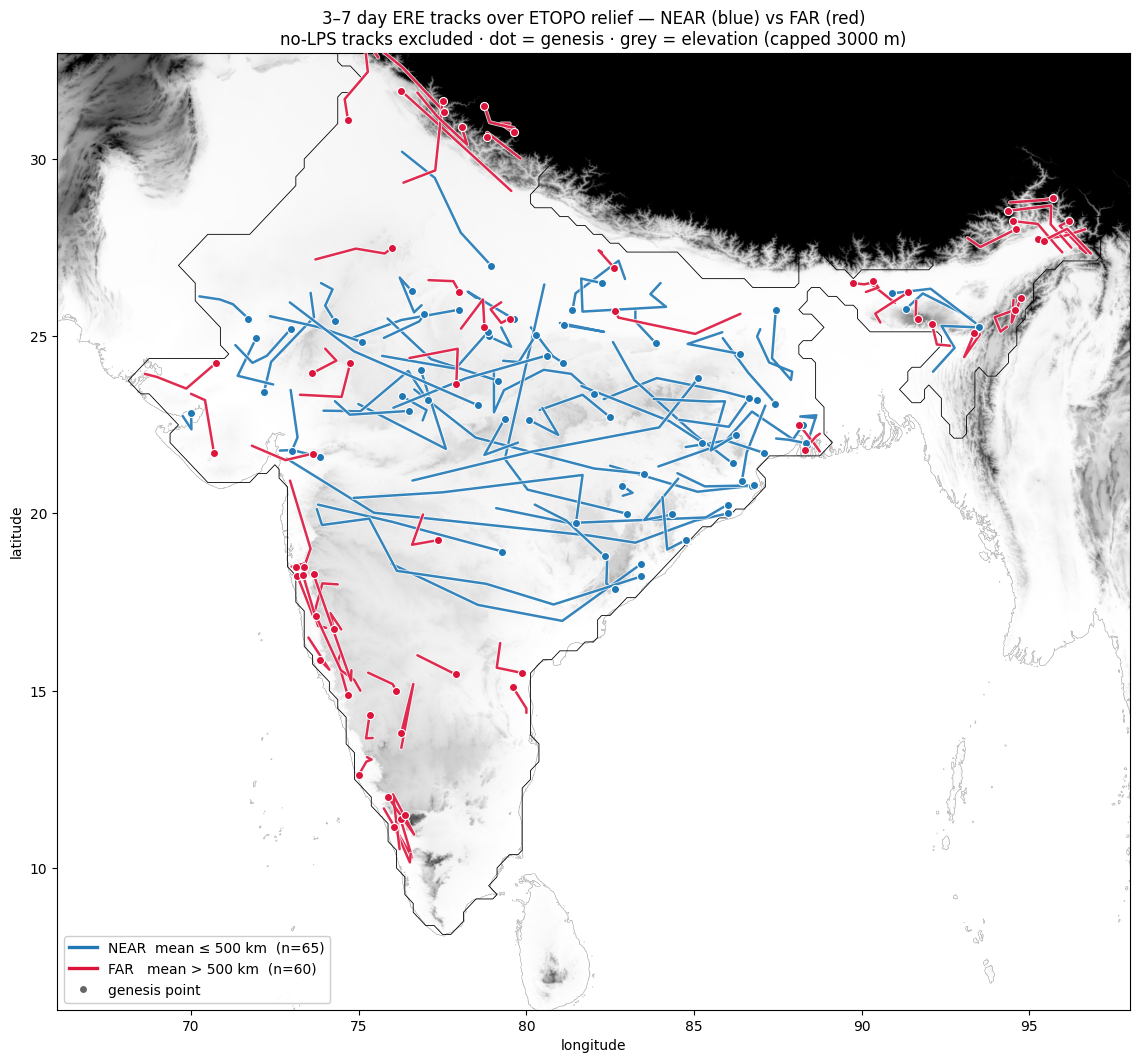

In [12]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
 
SPLIT_PANELS = False          # True → side-by-side NEAR-only / FAR-only panels
 
sel = track_class[track_class.duration > 2]                  # 3–7 day only
near_tns = sel.index[sel.lps_class == 'near']
far_tns  = sel.index[sel.lps_class == 'far']
print(f"3–7 day tracks plotted: near {len(near_tns)} · far {len(far_tns)} "
      f"(no-LPS excluded: {int((sel.lps_class=='no_lps').sum())})")
 
Z_land_plot = np.where(Z < 0, np.nan, Z)
LONg, LATg  = np.meshgrid(lon, lat)
halo = [pe.Stroke(linewidth=3.0, foreground='white', alpha=0.8), pe.Normal()]
 
def draw(ax, classes):
    ax.imshow(Z_land_plot, origin='lower',
              extent=[dem_lon[0], dem_lon[-1], dem_lat[0], dem_lat[-1]],
              cmap='Greys', vmin=0, vmax=3000, interpolation='bilinear', zorder=0)
    ax.contour(LONg, LATg, india_mask.astype(int), levels=[0.5],
               colors='k', linewidths=0.6, zorder=1)
    for klass, tns, col, z in classes:
        for tn in tns:
            g = stats_lps[stats_lps.track_num == tn].sort_values('day_of_track')
            ax.plot(g.centroid_lon, g.centroid_lat, '-', color=col, lw=1.8,
                    alpha=0.9, zorder=z, path_effects=halo, solid_capstyle='round')
            ax.scatter(g.centroid_lon.iloc[0], g.centroid_lat.iloc[0],
                       s=34, color=col, edgecolor='white', lw=0.8, zorder=z+2)
    ax.set_xlim(66, 98); ax.set_ylim(6, 33); ax.set_aspect(1.057)
    ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
 
if not SPLIT_PANELS:
    fig, ax = plt.subplots(figsize=(11.5, 12))
    draw(ax, [('near', near_tns, 'tab:blue', 3), ('far', far_tns, 'crimson', 4)])
    ax.legend(handles=[
        Line2D([0],[0], color='tab:blue', lw=2.4, label=f'NEAR  mean ≤ 500 km  (n={len(near_tns)})'),
        Line2D([0],[0], color='crimson',  lw=2.4, label=f'FAR   mean > 500 km  (n={len(far_tns)})'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='0.4',
               markeredgecolor='w', label='genesis point')],
        loc='lower left', framealpha=0.95)
    ax.set_title("3–7 day ERE tracks over ETOPO relief — NEAR (blue) vs FAR (red)\n"
                 "no-LPS tracks excluded · dot = genesis · grey = elevation (capped 3000 m)")
else:
    fig, axes = plt.subplots(1, 2, figsize=(20, 11))
    draw(axes[0], [('near', near_tns, 'tab:blue', 3)])
    axes[0].set_title(f"NEAR (≤500 km) — {len(near_tns)} tracks")
    draw(axes[1], [('far', far_tns, 'crimson', 4)])
    axes[1].set_title(f"FAR (>500 km) — {len(far_tns)} tracks")
plt.tight_layout(); plt.show()

In [13]:
import numpy as np, pandas as pd
from scipy.stats import mannwhitneyu
 
def hav(la1, lo1, la2, lo2):
    R=6371.0088; p1,p2=np.radians(la1),np.radians(la2); dphi=p2-p1; dl=np.radians(lo2-lo1)
    return 2*R*np.arcsin(np.sqrt(np.sin(dphi/2)**2+np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2))
 
def track_motion(tns):
    rows = []
    for tn in tns:
        g = stats_lps[stats_lps.track_num == tn].sort_values('day_of_track')
        la, lo = g.centroid_lat.to_numpy(), g.centroid_lon.to_numpy()
        if len(g) < 2: continue
        steps = hav(la[:-1], lo[:-1], la[1:], lo[1:])
        net   = hav(la[0], lo[0], la[-1], lo[-1]); path = steps.sum()
        rows.append(dict(tn=tn, dur=len(g), mean_step=steps.mean(), path=path,
                         net=net, straightness=net/path if path > 0 else np.nan))
    return pd.DataFrame(rows)
 
sel  = track_class[track_class.duration > 2]
F  = track_motion(sel.index[sel.lps_class == 'far'])
N  = track_motion(sel.index[sel.lps_class == 'near'])
NL = track_motion(sel.index[sel.lps_class == 'no_lps'])
 
def cliffs_delta(a, b):                     # P(a>b) − P(a<b); via Mann-Whitney U
    U = mannwhitneyu(a, b).statistic
    return 2*U/(len(a)*len(b)) - 1
 
print(f"3–7 day · FAR {len(F)} vs NEAR {len(N)}   (no-LPS {len(NL)} — sidelined, reference row only)\n")
print(f"{'metric':24s}{'FAR med':>10s}{'NEAR med':>10s}{'no-LPS med':>11s}{'MW p (far<near)':>17s}{'Cliff δ':>9s}")
for key, name in [('mean_step','mean daily step km'), ('net','net displacement km'),
                  ('path','path length km'), ('straightness','straightness net/path')]:
    p = mannwhitneyu(F[key].dropna(), N[key].dropna(), alternative='less').pvalue
    d = cliffs_delta(F[key].dropna(), N[key].dropna())
    print(f"{name:24s}{F[key].median():>10.1f}{N[key].median():>10.1f}"
          f"{NL[key].median():>11.1f}{p:>17.1e}{d:>+9.2f}")
print("\ncontext: union-far run (far+no-LPS, 91 tracks) gave 76.7 vs 123.7 km/day, p=1.4e-6.")
print("Cliff δ: −1 = far always smaller · 0 = no separation.")

3–7 day · FAR 60 vs NEAR 65   (no-LPS 31 — sidelined, reference row only)

metric                     FAR med  NEAR med no-LPS med  MW p (far<near)  Cliff δ
mean daily step km            75.1     123.7       91.2          7.7e-07    -0.50
net displacement km          117.9     224.5      130.7          5.7e-06    -0.46
path length km               160.7     272.2      212.7          3.8e-07    -0.51
straightness net/path          0.8       0.9        0.8          1.0e-01    -0.13

context: union-far run (far+no-LPS, 91 tracks) gave 76.7 vs 123.7 km/day, p=1.4e-6.
Cliff δ: −1 = far always smaller · 0 = no separation.


far 3–7 day tracks drawn: 60


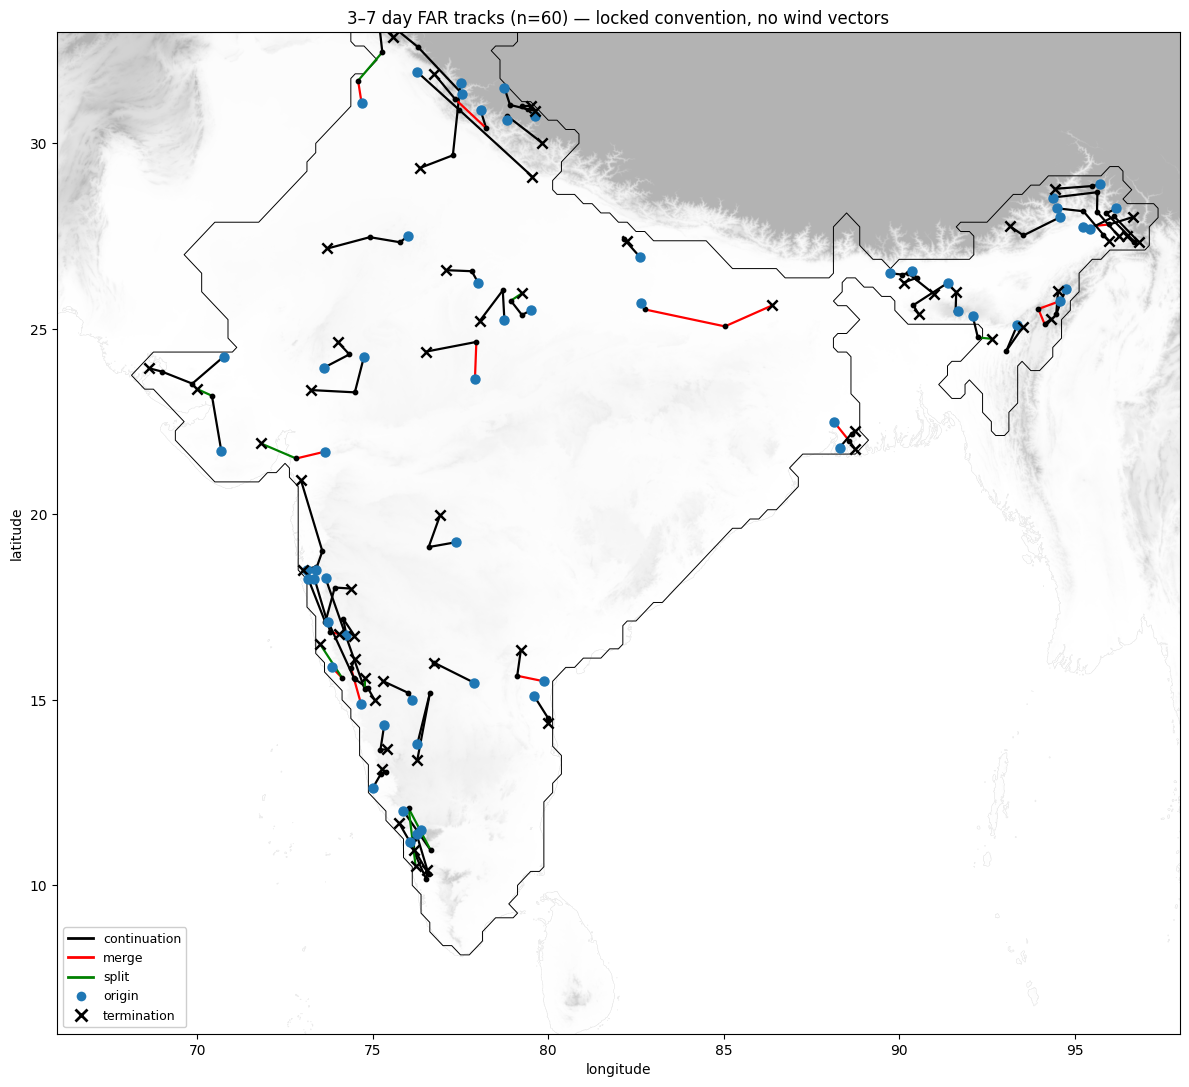

In [14]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
 
SHOW_TERRAIN = True
 
def seg_color(row):
    if bool(row.merge_event):                              return 'red'
    if bool(row.split_event) or row.link_type == 'split':  return 'green'
    return 'black'
 
def draw_track(ax, g, lw=1.6):
    la, lo = g.centroid_lat.to_numpy(), g.centroid_lon.to_numpy()
    for k in range(1, len(g)):
        ax.plot(lo[k-1:k+1], la[k-1:k+1], '-', color=seg_color(g.iloc[k]),
                lw=lw, zorder=3, solid_capstyle='round')
    if len(g) > 2:
        ax.scatter(lo[1:-1], la[1:-1], s=10, color='black', zorder=4)
    ax.scatter(lo[0],  la[0],  s=42, color='tab:blue', zorder=5)
    ax.scatter(lo[-1], la[-1], s=55, color='black', marker='x', lw=1.8, zorder=5)
 
def base_map(ax, terrain):
    if terrain:
        ax.imshow(np.where(Z < 0, np.nan, Z), origin='lower',
                  extent=[dem_lon[0], dem_lon[-1], dem_lat[0], dem_lat[-1]],
                  cmap='Greys', vmin=0, vmax=3000, alpha=0.30,
                  interpolation='bilinear', zorder=0)
    LONg, LATg = np.meshgrid(lon, lat)
    ax.contour(LONg, LATg, india_mask.astype(int), levels=[0.5],
               colors='k', linewidths=0.7, zorder=1)
    ax.set_xlim(66, 98); ax.set_ylim(6, 33); ax.set_aspect(1.057)
    ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
 
sel     = track_class[track_class.duration > 2]
far_tns = sel.index[sel.lps_class == 'far']
 
fig, ax = plt.subplots(figsize=(12, 12))
base_map(ax, SHOW_TERRAIN)
for tn in far_tns:
    g = stats_lps[stats_lps.track_num == tn].sort_values('day_of_track')
    draw_track(ax, g)
ax.legend(handles=[
    Line2D([0],[0], color='black', lw=2, label='continuation'),
    Line2D([0],[0], color='red',   lw=2, label='merge'),
    Line2D([0],[0], color='green', lw=2, label='split'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tab:blue',
           markersize=8, label='origin'),
    Line2D([0],[0], marker='x', color='black', lw=0, markersize=9,
           markeredgewidth=2, label='termination')],
    loc='lower left', framealpha=0.95, fontsize=9)
ax.set_title(f"3–7 day FAR tracks (n={len(far_tns)}) — locked convention, no wind vectors")
print(f"far 3–7 day tracks drawn: {len(far_tns)}")
plt.tight_layout(); plt.show()

1-day far: 4059 · 2-day far: 196


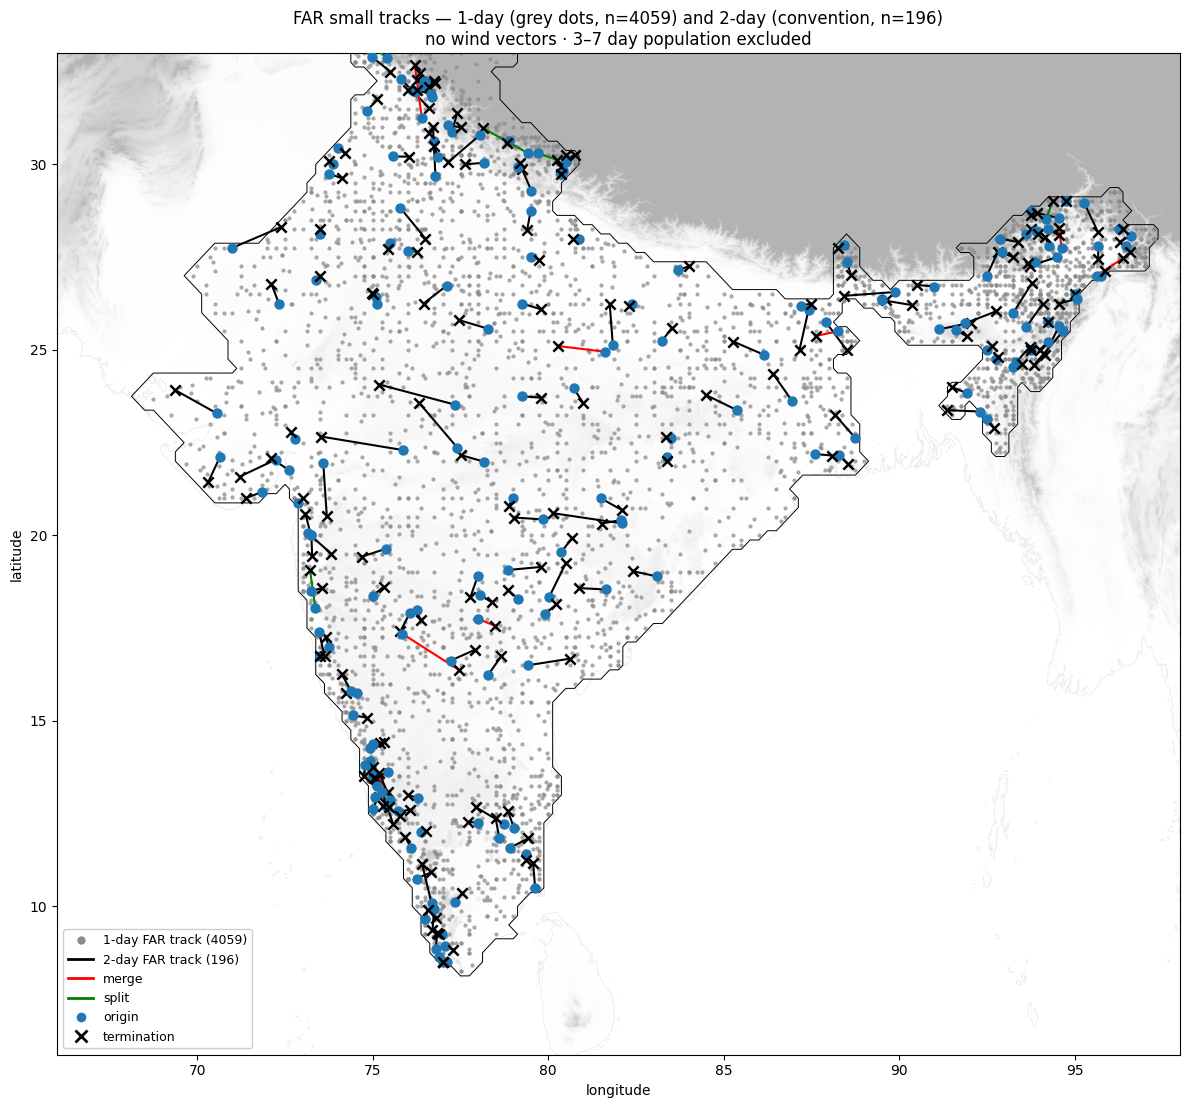

In [15]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
 
SHOW_TERRAIN = True
 
one_tns = track_class.index[(track_class.duration == 1) & (track_class.lps_class == 'far')]
two_tns = track_class.index[(track_class.duration == 2) & (track_class.lps_class == 'far')]
 
fig, ax = plt.subplots(figsize=(12, 12))
base_map(ax, SHOW_TERRAIN)                          # reuses CELL I helpers
 
g1 = stats_lps[stats_lps.track_num.isin(one_tns)]
ax.scatter(g1.centroid_lon, g1.centroid_lat, s=9, color='0.55',
           alpha=0.75, lw=0, zorder=2)              # 1-day = grey dots
 
for tn in two_tns:
    g = stats_lps[stats_lps.track_num == tn].sort_values('day_of_track')
    draw_track(ax, g, lw=1.5)                       # 2-day = full convention
 
ax.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor='0.55',
           markersize=7, label=f'1-day FAR track ({len(one_tns)})'),
    Line2D([0],[0], color='black', lw=2, label=f'2-day FAR track ({len(two_tns)})'),
    Line2D([0],[0], color='red',   lw=2, label='merge'),
    Line2D([0],[0], color='green', lw=2, label='split'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tab:blue',
           markersize=8, label='origin'),
    Line2D([0],[0], marker='x', color='black', lw=0, markersize=9,
           markeredgewidth=2, label='termination')],
    loc='lower left', framealpha=0.95, fontsize=9)
ax.set_title(f"FAR small tracks — 1-day (grey dots, n={len(one_tns)}) and "
             f"2-day (convention, n={len(two_tns)})\nno wind vectors · 3–7 day population excluded")
print(f"1-day far: {len(one_tns)} · 2-day far: {len(two_tns)}")
plt.tight_layout(); plt.show()

In [17]:
import numpy as np, pandas as pd
from scipy.stats import mannwhitneyu
 
HAVE_700 = ('u700' in globals()) and ('v700' in globals())
HAVE_Q   = ('q850' in globals())
HIGH_ELEV, EPS = 1400.0, 1e-12
 
date_to_idx = {ts.strftime('%Y%m%d'): i for i, ts in enumerate(times_pd)}
land_slope  = slope_max_025[india_mask & np.isfinite(slope_max_025)]
SLOPE_THR   = float(np.percentile(land_slope, 75))
sel = track_class[track_class.duration > 2]
sel = sel[sel.lps_class.isin(['near', 'far'])]
 
rows = []
for r in stats_lps[stats_lps.track_num.isin(sel.index)].itertuples(index=False):
    t = date_to_idx[r.date]; m = (Label8[t] == int(r.day_lbl))
    if not m.any(): continue
    sl, el = slope_max_025[m], elev_025[m]
    gx, gy = dzdx_025[m], dzdy_025[m]
    ok = np.isfinite(sl) & np.isfinite(gx) & np.isfinite(gy)
    if not ok.any(): continue
    elev_fp = float(np.nanmean(el)); use700 = HAVE_700 and elev_fp > 1200
    uu = (u700 if use700 else u_wind)[t][m]; vv = (v700 if use700 else v_wind)[t][m]
    qq = q850[t][m]*1000 if HAVE_Q else np.ones_like(uu)
    Fdry = uu*gx + vv*gy; F = qq*Fdry
    gmag = np.hypot(gx, gy); A = float(np.nansum(F[ok])/(np.nansum((qq*np.hypot(uu,vv)*gmag)[ok])+EPS))
    steep = ok & (sl >= SLOPE_THR)
    rows.append(dict(tn=int(r.track_num), high=(not use700) and elev_fp > HIGH_ELEV,
                     slope=float(np.nanmax(sl[ok])), A_grad=A,
                     w_steep=float(100*np.nanmean(F[steep])) if steep.any() else np.nan,
                     w_pos=float(np.nanmean(F[ok] > 0))))
D = pd.DataFrame(rows)
 
VITAL = [('slope',  'slope max  (m/km)'),
         ('A_grad', 'wind-uphill  (-1..1)'),
         ('w_steep','ascent on steep  (cm/s)'),
         ('w_pos',  'frac days ascending')]
 
def cliffs(a, b):
    return 2*mannwhitneyu(a, b).statistic/(len(a)*len(b)) - 1
 
def clean_table(days, label):
    P = days.groupby('tn')[[k for k,_ in VITAL]].mean(); P['cls'] = sel.lps_class
    F_, N_ = P[P.cls=='far'], P[P.cls=='near']
    print(f"\n{label}  ·  far {len(F_)} vs near {len(N_)} tracks")
    out = []
    for k, name in VITAL:
        a, b = F_[k].dropna(), N_[k].dropna()
        p = mannwhitneyu(a, b, alternative='greater').pvalue
        nx = int((a > b.median()).sum())
        out.append({'metric': name, 'far': round(a.median(),2), 'near': round(b.median(),2),
                    'δ': f"{cliffs(a,b):+.2f}", 'p': f"{p:.0e}", 'far>near': f"{nx}/{len(a)}"})
    print(pd.DataFrame(out).to_string(index=False))
 
mode = ('moisture-flux' if HAVE_Q else 'dry-wind') + (' + 700hPa' if HAVE_700 else ' · 850 only')
print(f"uprising test [{mode}]  ·  δ = Cliff's (+1 = far always higher)  ·  p one-sided far>near")
clean_table(D, "ALL days")
if not HAVE_700 and D.high.any():
    clean_table(D[~D.high], f"850-TRUSTWORTHY days (drop {int(D.high.sum())} footprints >1400 m)")

uprising test [dry-wind · 850 only]  ·  δ = Cliff's (+1 = far always higher)  ·  p one-sided far>near

ALL days  ·  far 60 vs near 65 tracks
                 metric    far   near     δ     p far>near
      slope max  (m/km) 216.95 115.52 +0.39 7e-05    43/60
   wind-uphill  (-1..1)   0.28   0.08 +0.30 2e-03    43/60
ascent on steep  (cm/s)   1.95  -0.16 +0.46 4e-05    42/51
    frac days ascending   0.68   0.52 +0.30 2e-03    44/60

850-TRUSTWORTHY days (drop 39 footprints >1400 m)  ·  far 53 vs near 65 tracks
                 metric    far   near     δ     p far>near
      slope max  (m/km) 182.38 115.52 +0.30 3e-03    36/53
   wind-uphill  (-1..1)   0.26   0.08 +0.29 3e-03    38/53
ascent on steep  (cm/s)   3.37  -0.16 +0.50 2e-05    36/44
    frac days ascending   0.72   0.52 +0.31 2e-03    38/53


In [28]:
import numpy as np, pandas as pd, time
 
SEEDS, B_PER_SEED, MAX_TRY = [0, 1, 2, 3, 4], 1000, 300
NAMES = ['slope m/km', 'rough m', 'frac_steep', 'w_pos_days', 'A_grad']
 
date_to_idx = {ts.strftime('%Y%m%d'): i for i, ts in enumerate(times_pd)}
n_lat, n_lon = len(lat), len(lon)
land_slope = slope_max_025[india_mask & np.isfinite(slope_max_025)]
SLOPE_THR  = float(np.percentile(land_slope, 75))
sel = track_class[track_class.duration > 2]
far_tns = list(sel.index[sel.lps_class == 'far'])
 
fp = {}
for tn in far_tns:
    g = stats_lps[stats_lps.track_num == tn].sort_values('day_of_track')
    days = []
    for r in g.itertuples(index=False):
        t = date_to_idx[r.date]
        ii, jj = np.where(Label8[t] == int(r.day_lbl))
        if ii.size: days.append((t, ii, jj))
    if days: fp[tn] = days
 
def tmetrics(days, di, dj):
    sv, rv, fv, wv, av = [], [], [], [], []
    for t, ii, jj in days:
        i2, j2 = ii + di, jj + dj
        if i2.min() < 0 or i2.max() >= n_lat or j2.min() < 0 or j2.max() >= n_lon:  return None
        if india_mask[i2, j2].mean() < 0.90:                                          return None
        sl = slope_max_025[i2, j2]; okc = np.isfinite(sl)
        if okc.mean() < 0.50:                                                         return None
        gx, gy = dzdx_025[i2, j2], dzdy_025[i2, j2]
        uu, vv = u_wind[t][i2, j2], v_wind[t][i2, j2]
        F = uu*np.nan_to_num(gx) + vv*np.nan_to_num(gy)
        spd = np.hypot(uu, vv); gmag = np.hypot(np.nan_to_num(gx), np.nan_to_num(gy))
        sv.append(np.nanmax(sl[okc])); rv.append(np.nanmean(rough_025[i2, j2]))
        fv.append(np.nanmean(sl[okc] >= SLOPE_THR)); wv.append(float(np.nanmean(F[okc]) > 0))
        av.append(np.nansum(F[okc]) / (np.nansum((spd*gmag)[okc]) + 1e-12))
    return (np.mean(sv), np.mean(rv), np.mean(fv), np.mean(wv), np.mean(av))
 
obs = np.median(np.array([tmetrics(v, 0, 0) for v in fp.values()]), axis=0)
print(f"far tracks {len(fp)} · object-days {sum(len(v) for v in fp.values())}")
print("observed medians:", {n: round(float(o), 3) for n, o in zip(NAMES, obs)})
 
t0 = time.time(); null = {s: [] for s in SEEDS}; kept0 = 0
for s in SEEDS:
    rng = np.random.default_rng(s)
    for _ in range(B_PER_SEED):
        vals = []
        for days in fp.values():
            res = None
            for _ in range(MAX_TRY):
                res = tmetrics(days, int(rng.integers(-n_lat+1, n_lat)),
                                     int(rng.integers(-n_lon+1, n_lon)))
                if res is not None: break
            if res is None: res = tmetrics(days, 0, 0); kept0 += 1
            vals.append(res)
        null[s].append(np.median(np.array(vals), axis=0))
    print(f"seed {s} done · {time.time()-t0:4.0f}s")
allN = np.array([v for s in SEEDS for v in null[s]])
 
rowsM = []
for k, name in enumerate(NAMES):
    nv = allN[:, k]; ge = int((nv >= obs[k]).sum())
    rowsM.append({'metric': name, 'observed': round(float(obs[k]), 2),
                  'null_mean': round(float(nv.mean()), 2),
                  'σ>null': round(float((obs[k]-nv.mean())/(nv.std()+1e-12)), 1),
                  'p': f"{(1+ge)/(len(nv)+1):.0e}",
                  'seeds_ok': f"{sum(int((np.array(null[s])[:,k]>=obs[k]).sum())==0 for s in SEEDS)}/{len(SEEDS)}"})
print(f"\nrelocation null · {allN.shape[0]} shuffles · failed placements kept at origin: {kept0}")
print("σ>null = SDs above the null mean (report this, not a ratio: baselines differ)\n")
print(pd.DataFrame(rowsM).to_string(index=False))
 

far tracks 60 · object-days 196
observed medians: {'slope m/km': 216.947, 'rough m': 111.799, 'frac_steep': 0.481, 'w_pos_days': 0.75, 'A_grad': 0.281}
seed 0 done ·   92s
seed 1 done ·  189s
seed 2 done ·  294s
seed 3 done ·  388s
seed 4 done ·  481s

relocation null · 5000 shuffles · failed placements kept at origin: 53
σ>null = SDs above the null mean (report this, not a ratio: baselines differ)

    metric  observed  null_mean  σ>null     p seeds_ok
slope m/km    216.95      93.48    12.4 2e-04      5/5
   rough m    111.80      41.48    15.7 2e-04      5/5
frac_steep      0.48       0.05    18.7 2e-04      5/5
w_pos_days      0.75       0.50     1.9 2e-04      5/5
    A_grad      0.28       0.00     4.3 2e-04      5/5


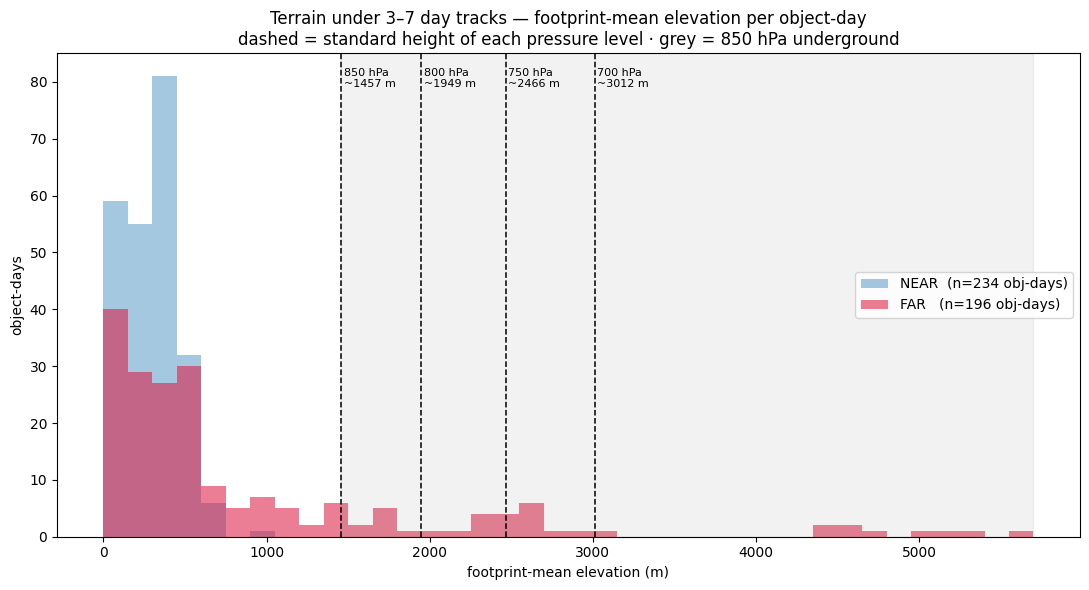


FAR:  196 object-days · 60 tracks
  footprint-mean elev  median   459 m · p90  2446 m · max  5629 m
  object-days above 1400 m (850 underground): 37 (19%)
  tracks with ANY day above 1400 m: 16 of 60

NEAR:  234 object-days · 65 tracks
  footprint-mean elev  median   305 m · p90   503 m · max  1046 m
  object-days above 1400 m (850 underground): 0 (0%)
  tracks with ANY day above 1400 m: 0 of 65

fraction of FAR object-days above each level (would need the NEXT level up):
  > 850 hPa (1457 m):  37 days (18.9%)
  > 800 hPa (1949 m):  28 days (14.3%)
  > 750 hPa (2466 m):  20 days (10.2%)
  > 700 hPa (3012 m):  10 days ( 5.1%)

RECOMMENDATION: highest far footprint ~5629 m. Download levels: 800, 750, 700 hPa.
Nearest-above-ground rule for the analysis: 850 if elev<1400 m · 800 if <1950 m · 750 if <2470 m · else 700.


In [19]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
 
# standard-atmosphere geopotential height of each candidate level (m)
PLEVELS = {'850': 1457, '800': 1949, '750': 2466, '700': 3012}
UNDERGROUND = PLEVELS['850']          # above this, 850 hPa is at/below ground
 
date_to_idx = {ts.strftime('%Y%m%d'): i for i, ts in enumerate(times_pd)}
 
def footprint_elev(tns):
    """returns (per-object-day footprint-mean elev, per-track max footprint-mean elev)"""
    day_mean = []
    trk_max  = {}
    for r in stats_lps[stats_lps.track_num.isin(tns)].itertuples(index=False):
        t = date_to_idx[r.date]; m = (Label8[t] == int(r.day_lbl))
        if not m.any(): continue
        e = elev_025[m]; e = e[np.isfinite(e)]
        if e.size:
            em = float(e.mean()); day_mean.append(em)
            trk_max[r.track_num] = max(trk_max.get(r.track_num, -1e9), em)
    return np.array(day_mean), np.array(list(trk_max.values()))
 
sel      = track_class[track_class.duration > 2]
far_day,  far_trk  = footprint_elev(sel.index[sel.lps_class == 'far'])
near_day, near_trk = footprint_elev(sel.index[sel.lps_class == 'near'])
 
# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
hi   = max(far_day.max(), near_day.max())
bins = np.arange(0, hi + 200, 150)
ax.hist(near_day, bins=bins, color='tab:blue', alpha=0.40, label=f'NEAR  (n={len(near_day)} obj-days)')
ax.hist(far_day,  bins=bins, color='crimson',  alpha=0.55, label=f'FAR   (n={len(far_day)} obj-days)')
ax.axvspan(UNDERGROUND, bins[-1], color='0.5', alpha=0.10)          # 850-underground zone
ymax = ax.get_ylim()[1]
for name, h in PLEVELS.items():
    ax.axvline(h, ls='--', lw=1.1, color='k')
    ax.text(h + 15, ymax * 0.97, f'{name} hPa\n~{h} m', va='top', ha='left', fontsize=8)
ax.set_xlabel('footprint-mean elevation (m)'); ax.set_ylabel('object-days')
ax.set_title('Terrain under 3–7 day tracks — footprint-mean elevation per object-day\n'
             'dashed = standard height of each pressure level · grey = 850 hPa underground')
ax.legend(loc='center right'); plt.tight_layout(); plt.show()
 
# ── which levels to download ────────────────────────────────────────────────────
def summ(day, trk, lab):
    print(f"\n{lab}:  {len(day)} object-days · {len(trk)} tracks")
    print(f"  footprint-mean elev  median {np.median(day):5.0f} m · "
          f"p90 {np.percentile(day,90):5.0f} m · max {day.max():5.0f} m")
    print(f"  object-days above 1400 m (850 underground): "
          f"{int((day>UNDERGROUND).sum())} ({100*(day>UNDERGROUND).mean():.0f}%)")
    print(f"  tracks with ANY day above 1400 m: {int((trk>UNDERGROUND).sum())} of {len(trk)}")
 
summ(far_day, far_trk, "FAR")
summ(near_day, near_trk, "NEAR")
 
print("\nfraction of FAR object-days above each level (would need the NEXT level up):")
for name, h in PLEVELS.items():
    print(f"  > {name} hPa ({h} m): {int((far_day>h).sum()):3d} days ({100*(far_day>h).mean():4.1f}%)")
 
topf = far_day.max()
need = [n for n, h in PLEVELS.items() if n != '850' and h < topf + 300]
print(f"\nRECOMMENDATION: highest far footprint ~{topf:.0f} m. Download levels: "
      f"{', '.join(need) if need else '800'} hPa.")
print("Nearest-above-ground rule for the analysis: 850 if elev<1400 m · 800 if <1950 m · "
      "750 if <2470 m · else 700.")
 

**WORKING WITH 700, 750, 800, 850 HPA DATA**

In [20]:
import glob, os, numpy as np, pandas as pd, xarray as xr
 
hit = glob.glob("/kaggle/input/**/wind_daily_uv700.nc", recursive=True)
assert hit, "wind_daily_uv700.nc not found under /kaggle/input — is the dataset added to the notebook?"
DATA_DIR = os.path.dirname(sorted(hit)[0])
print("DATA_DIR =", DATA_DIR)
 
LEVELS = [700, 750, 800, 850]
level_files = {L: os.path.join(DATA_DIR, f"wind_daily_uv{L}.nc") for L in LEVELS}
for L, f in level_files.items():
    print(f"  {L} hPa: {'OK ' if os.path.exists(f) else 'MISSING'} {os.path.basename(f)}")
    assert os.path.exists(f), f"missing {f}"
 
def find(ds, cands):
    for c in cands:
        if c in ds.variables or c in ds.coords or c in ds.dims: return c
    return None
 
ds0 = xr.open_dataset(level_files[700])
print("\n--- structure of wind_daily_uv700.nc ---")
print(ds0)
UN  = find(ds0, ['u', 'u_component_of_wind', 'u_wind', 'U'])
VN  = find(ds0, ['v', 'v_component_of_wind', 'v_wind', 'V'])
TN  = find(ds0, ['valid_time', 'time', 'date'])
LAN = find(ds0, ['latitude', 'lat'])
LON = find(ds0, ['longitude', 'lon'])
LN  = find(ds0, ['pressure_level', 'level', 'plev', 'isobaricInhPa', 'lev'])
print("\nresolved names:", dict(u=UN, v=VN, time=TN, lat=LAN, lon=LON, level=LN))
assert None not in (UN, VN, TN, LAN, LON), "could not resolve u/v/time/lat/lon — inspect the print above"
print("time span:", str(pd.to_datetime(ds0[TN].values).min().date()),
      "→", str(pd.to_datetime(ds0[TN].values).max().date()),
      "| n steps:", ds0.sizes[TN], "| u units:", ds0[UN].attrs.get('units'))
ds0.close()
print("V1 ✓  four level files present; names resolved")
 

DATA_DIR = /kaggle/input/datasets/divyanshyecho/era5-uv850-mean
  700 hPa: OK  wind_daily_uv700.nc
  750 hPa: OK  wind_daily_uv750.nc
  800 hPa: OK  wind_daily_uv800.nc
  850 hPa: OK  wind_daily_uv850.nc

--- structure of wind_daily_uv700.nc ---
<xarray.Dataset> Size: 1GB
Dimensions:         (time: 3050, latitude: 141, longitude: 161)
Coordinates:
  * time            (time) datetime64[ns] 24kB 2000-06-01 ... 2024-09-30
  * latitude        (latitude) float64 1kB 40.0 39.75 39.5 ... 5.5 5.25 5.0
  * longitude       (longitude) float64 1kB 60.0 60.25 60.5 ... 99.5 99.75 100.0
    number          int64 8B ...
    pressure_level  float64 8B ...
Data variables:
    u               (time, latitude, longitude) float32 277MB ...
    v               (time, latitude, longitude) float32 277MB ...
    speed           (time, latitude, longitude) float32 277MB ...
    direction       (time, latitude, longitude) float32 277MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription

In [23]:
target = np.array([pd.Timestamp(t).strftime('%Y%m%d') for t in pd.to_datetime(times_pd)])
 
def load_level(path):
    ds = xr.open_dataset(path)
    u, v = ds[UN], ds[VN]
    if LN is not None and LN in u.dims:                 # squeeze a singleton level if present
        u, v = u.isel({LN: 0}), v.isel({LN: 0})
    # exact grid check (values, any order) then reorder to the notebook's lat/lon
    la, lo = np.asarray(ds[LAN].values), np.asarray(ds[LON].values)
    ok = (len(la) == len(lat) and len(lo) == len(lon)
          and np.allclose(np.sort(la), np.sort(np.asarray(lat)), atol=1e-6)
          and np.allclose(np.sort(lo), np.sort(np.asarray(lon)), atol=1e-6))
    assert ok, f"GRID MISMATCH in {os.path.basename(path)} vs the IMERG/850 grid"
    u = u.reindex({LAN: np.asarray(lat), LON: np.asarray(lon)})
    v = v.reindex({LAN: np.asarray(lat), LON: np.asarray(lon)})
    d = np.array([pd.Timestamp(t).strftime('%Y%m%d') for t in pd.to_datetime(ds[TN].values)])
    miss = sorted(set(target) - set(d))
    assert not miss, f"{os.path.basename(path)} missing {len(miss)} IMERG days e.g. {miss[:4]}"
    u = u.assign_coords(_d=(TN, d)).set_index({TN: '_d'}).sel({TN: target})
    v = v.assign_coords(_d=(TN, d)).set_index({TN: '_d'}).sel({TN: target})
    ds.close()
    return np.asarray(u.values, 'float32'), np.asarray(v.values, 'float32')
 
u700, v700 = load_level(level_files[700])
u750, v750 = load_level(level_files[750])
u800, v800 = load_level(level_files[800])
u850, v850 = load_level(level_files[850])
tgt_shape = (len(target), len(lat), len(lon))
for nm, A in [('u700',u700),('u850',u850),('v800',v800)]:
    assert A.shape == tgt_shape, f"{nm} shape {A.shape} != {tgt_shape}"
print("aligned u700/…/u850 shape", u700.shape, "→ matches (n_days, n_lat, n_lon)", tgt_shape)
 
# --- consistency of the dataset's 850 with the notebook's existing u_wind (if present) ---
if 'u_wind' in globals() and u_wind is not None and u_wind.shape == u850.shape:
    both = np.isfinite(u_wind) & np.isfinite(u850)
    du = np.nanmax(np.abs(u_wind[both] - u850[both])) if both.any() else np.nan
    print(f"dataset-850 vs existing u_wind: max |Δu| on overlap = {du:.3g} m/s "
          f"({'identical ✓' if du < 1e-3 else 'DIFFER — investigate before proceeding'})")
else:
    print("no pre-existing u_wind in scope — using the dataset's 850 as the reference.")
# use the dataset's own 850 as the 850 reference downstream (maximally consistent set)
u_wind, v_wind = u850, v850
print("V2 ✓  all four levels aligned to IMERG days, grid identical; 850 set as reference")

aligned u700/…/u850 shape (3050, 141, 161) → matches (n_days, n_lat, n_lon) (3050, 141, 161)
dataset-850 vs existing u_wind: max |Δu| on overlap = 0 m/s (identical ✓)
V2 ✓  all four levels aligned to IMERG days, grid identical; 850 set as reference


In [25]:
# %% ── V6 · build per-cell 'best wind' + population split (run before FINAL-0) ──
import numpy as np, pandas as pd

BOUNDS = [(-1e9, 1400, 850), (1400, 1950, 800), (1950, 2470, 750), (2470, 3010, 700)]
EXCLUDE_ABOVE = 3010.0

level_of_cell = np.full(elev_025.shape, -1, dtype=int)          # -1 = excluded / not land
for lo, hi_, lv_ in BOUNDS:
    level_of_cell[np.isfinite(elev_025) & (elev_025 >= lo) & (elev_025 < hi_)] = lv_

src = {850:(u850,v850), 800:(u800,v800), 750:(u750,v750), 700:(u700,v700)}
u_best = np.full(u850.shape, np.nan, dtype='float32')
v_best = np.full(u850.shape, np.nan, dtype='float32')
for lv_, (U, V) in src.items():
    c = (level_of_cell == lv_)
    u_best[:, c] = U[:, c]; v_best[:, c] = V[:, c]

print("cells per level (land only):")
for lv_ in [850, 800, 750, 700]:
    print(f"  {lv_} hPa: {int((level_of_cell == lv_).sum()):6d}")
print(f"  EXCLUDED (>{EXCLUDE_ABOVE:.0f} m): "
      f"{int((np.isfinite(elev_025) & (elev_025 >= EXCLUDE_ABOVE)).sum()):6d}")

# --- far 3–7 day population split ---
date_to_idx = {d: i for i, d in enumerate([pd.Timestamp(t).strftime('%Y%m%d') for t in times_pd])}
sel = track_class[(track_class.duration > 2) & (track_class.lps_class == 'far')]
rows = []
for r in stats_lps[stats_lps.track_num.isin(sel.index)].itertuples(index=False):
    t = date_to_idx.get(r.date); m = (Label8[t] == int(r.day_lbl)) if t is not None else None
    if m is None or not m.any(): continue
    e = elev_025[m]; e = e[np.isfinite(e)]
    if not e.size: continue
    rows.append(dict(tn=int(r.track_num), emean=float(e.mean()),
                     min_valid=float((level_of_cell[m] > 0).mean())))
F = pd.DataFrame(rows)
per_trk = F.groupby('tn').min_valid.min()

band = pd.cut(F.emean, [0, 1400, 1950, 2470, 3010, 1e9],
              labels=['≤1400 (850)', '1400-1950 (800)', '1950-2470 (750)',
                      '2470-3010 (700)', '>3010 (excl)'])
print(f"\nfar 3–7 day: {per_trk.shape[0]} tracks · {len(F)} object-days")
print("object-days by footprint-mean elevation band:")
print(band.value_counts().reindex(band.cat.categories).to_string())
print(f"\nrecoverable (1400–3010 m): {int(((F.emean>1400)&(F.emean<=3010)).sum())} object-days")
print(f"excluded (>3010 m):        {int((F.emean>3010).sum())} object-days")
print(f"tracks fully unusable (all cells >3010 m): {int((per_trk == 0).sum())}")
print(f"tracks usable for analysis: {int((per_trk > 0).sum())} of {per_trk.shape[0]}")
u_best[:, np.isfinite(elev_025) & (elev_025 >= EXCLUDE_ABOVE)] = np.nan   # ensure NaN above 3010
v_best[:, np.isfinite(elev_025) & (elev_025 >= EXCLUDE_ABOVE)] = np.nan
print("\nu_best / v_best / level_of_cell ready → run FINAL-0.")

cells per level (land only):
  850 hPa:   8359
  800 hPa:    663
  750 hPa:    392
  700 hPa:    499
  EXCLUDED (>3010 m):   4000

far 3–7 day: 60 tracks · 196 object-days
object-days by footprint-mean elevation band:
≤1400 (850)        157
1400-1950 (800)     11
1950-2470 (750)      8
2470-3010 (700)     10
>3010 (excl)        10

recoverable (1400–3010 m): 29 object-days
excluded (>3010 m):        10 object-days
tracks fully unusable (all cells >3010 m): 3
tracks usable for analysis: 57 of 60

u_best / v_best / level_of_cell ready → run FINAL-0.


In [26]:
import numpy as np, pandas as pd
from scipy.stats import mannwhitneyu
 
assert 'u_best' in globals() and 'level_of_cell' in globals(), "run the validation suite (through V6) first"
assert np.isnan(u_best[:, np.isfinite(elev_025) & (elev_025 > 3010)]).all(), \
       "u_best should be NaN above 3010 m — rebuild it in V6"
 
land_slope = slope_max_025[india_mask & np.isfinite(slope_max_025)]
SLOPE_THR  = float(np.percentile(land_slope, 75))
print(f"land slope (m/km): p50 {np.percentile(land_slope,50):.1f} · p75 {SLOPE_THR:.1f} · "
      f"p90 {np.percentile(land_slope,90):.1f} · max {land_slope.max():.1f}")
print("  ^ if max is in the many-hundreds/thousands, the coastline-cliff artifact is still in "
      "slope — rerun Cell E (land-only) before proceeding.")
 
date_to_idx = {d: i for i, d in enumerate([pd.Timestamp(t).strftime('%Y%m%d') for t in times_pd])}
sel = track_class[(track_class.duration > 2) & (track_class.lps_class.isin(['near','far']))]
 
# fully-excluded far tracks = every footprint cell above 3010 m (no usable wind anywhere)
def valid_frac(tn):
    fr = []
    for r in stats_lps[stats_lps.track_num == tn].itertuples(index=False):
        t = date_to_idx.get(r.date); m = (Label8[t] == int(r.day_lbl)) if t is not None else None
        if m is None or not m.any(): continue
        fr.append((level_of_cell[m] > 0).mean())
    return np.mean(fr) if fr else 0.0
 
far_all = sel.index[sel.lps_class == 'far']
excluded = [int(tn) for tn in far_all if valid_frac(tn) == 0]
print(f"\nfar 3–7 day tracks: {len(far_all)} · near: {int((sel.lps_class=='near').sum())}")
print(f"fully excluded (all cells >3010 m, no valid wind): {len(excluded)} tracks {excluded}")
print("these keep valid TERRAIN metrics but are dropped from the WIND/ascent metrics.")

land slope (m/km): p50 32.2 · p75 98.4 · p90 274.9 · max 699.6
  ^ if max is in the many-hundreds/thousands, the coastline-cliff artifact is still in slope — rerun Cell E (land-only) before proceeding.

far 3–7 day tracks: 60 · near: 65
fully excluded (all cells >3010 m, no valid wind): 2 tracks [4493, 5442]
these keep valid TERRAIN metrics but are dropped from the WIND/ascent metrics.


In [27]:
EPS = 1e-12
rows = []
for r in stats_lps[stats_lps.track_num.isin(sel.index)].itertuples(index=False):
    t = date_to_idx.get(r.date)
    if t is None: continue
    m = (Label8[t] == int(r.day_lbl))
    if not m.any(): continue
    sl, ro, el = slope_max_025[m], rough_025[m], elev_025[m]
    gx, gy     = dzdx_025[m], dzdy_025[m]
    uu, vv     = u_best[t][m], v_best[t][m]                       # per-cell above-ground wind
    okT = np.isfinite(sl)                                         # terrain-valid cells
    okW = okT & np.isfinite(uu) & np.isfinite(gx) & np.isfinite(gy)   # wind-valid cells (≤3010 m)
    if not okT.any(): continue
    F   = uu*gx + vv*gy
    A   = (np.nansum(F[okW]) / (np.nansum((np.hypot(uu,vv)*np.hypot(gx,gy))[okW]) + EPS)
           if okW.any() else np.nan)
    steep = okW & (sl >= SLOPE_THR)
    rows.append(dict(tn=int(r.track_num), cls=sel.lps_class[r.track_num],
                     slope=float(np.nanmax(sl[okT])),
                     rough=float(np.nanmean(ro[okT])),
                     frac_steep=float((sl[okT] >= SLOPE_THR).mean()),
                     A_grad=A,
                     w_steep=float(100*np.nanmean(F[steep])) if steep.any() else np.nan,
                     day_up=(float(np.nanmean(F[okW]) > 0) if okW.any() else np.nan)))
D = pd.DataFrame(rows)
P = D.groupby('tn').agg(cls=('cls','first'),
                        slope=('slope','mean'), rough=('rough','mean'),
                        frac_steep=('frac_steep','mean'), A_grad=('A_grad','mean'),
                        w_steep=('w_steep','mean'), w_pos_days=('day_up','mean'))
Fp, Np_ = P[P.cls=='far'], P[P.cls=='near']
 
def cliffs(a, b): return 2*mannwhitneyu(a, b).statistic/(len(a)*len(b)) - 1
 
METRICS = [('slope','slope max (m/km)'), ('rough','roughness (m)'),
           ('frac_steep','frac cells steep'), ('A_grad','wind-uphill (-1..1)'),
           ('w_steep','ascent on steep (cm/s)'), ('w_pos_days','frac days ascending')]
print("UPRISING TEST — far vs near, 3–7 day, per-cell above-ground wind (high tracks included)")
print(f"far {len(Fp)} vs near {len(Np_)} tracks · δ = Cliff's · p one-sided far>near\n")
out = []
for k, name in METRICS:
    a, b = Fp[k].dropna(), Np_[k].dropna()
    out.append({'metric': name, 'nF': len(a), 'nN': len(b),
                'far': round(a.median(),2), 'near': round(b.median(),2),
                'p': f"{mannwhitneyu(a,b,alternative='greater').pvalue:.0e}",
                'δ': f"{cliffs(a,b):+.2f}"})
print(pd.DataFrame(out).to_string(index=False))
pct = 100*np.mean(land_slope <= Fp.slope.median())
print(f"\nabsolute anchor: median far slope = {round(float(Fp.slope.median()))} m/km "
      f"= {pct:.0f}th percentile of all India-land slope.")

UPRISING TEST — far vs near, 3–7 day, per-cell above-ground wind (high tracks included)
far 60 vs near 65 tracks · δ = Cliff's · p one-sided far>near

                metric  nF  nN    far   near     p     δ
      slope max (m/km)  60  65 216.95 115.52 7e-05 +0.39
         roughness (m)  60  65 111.80  37.92 4e-06 +0.46
      frac cells steep  60  65   0.48   0.07 8e-06 +0.45
   wind-uphill (-1..1)  58  65   0.30   0.08 1e-03 +0.32
ascent on steep (cm/s)  49  51   3.25  -0.16 8e-06 +0.50
   frac days ascending  58  65   0.88   0.50 9e-04 +0.32

absolute anchor: median far slope = 217 m/km = 87th percentile of all India-land slope.


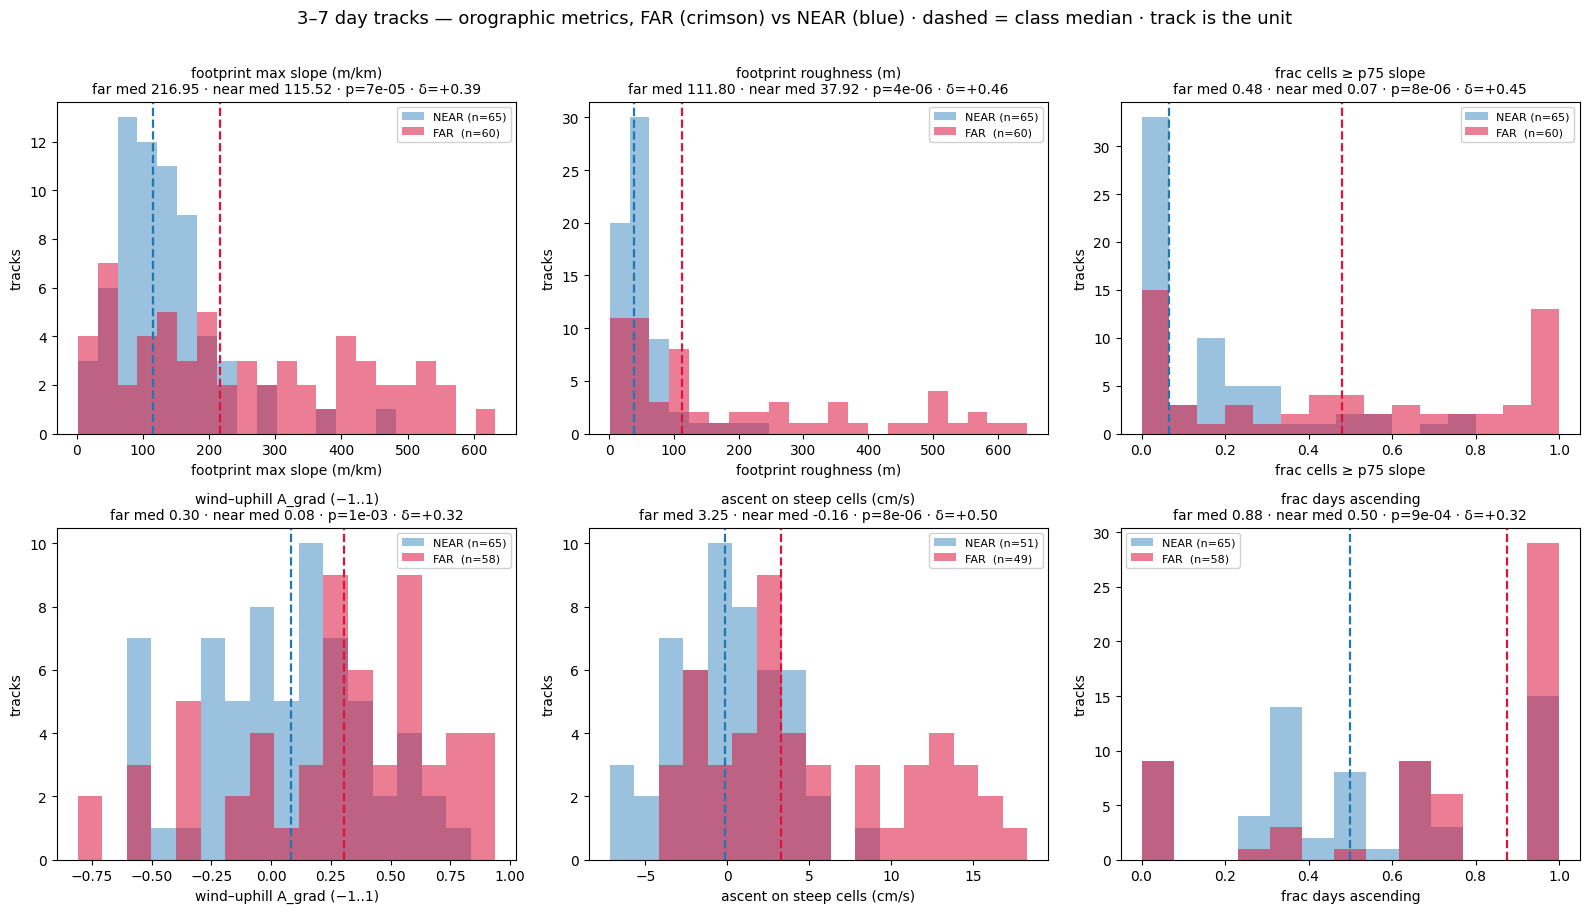

In [29]:
# ── Q1 · far-vs-near distributions behind the UPRISING TEST table (run AFTER Cell 25) ──
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

assert 'P' in globals(), "run the UPRISING TEST cell (Cell 25) first — it builds P / Fp / Np_"
Fp_ = P[P.cls == 'far']; Np_2 = P[P.cls == 'near']

def cliffs(a, b):
    return 2*mannwhitneyu(a, b).statistic/(len(a)*len(b)) - 1

# (key, nice label, n-bins). One-sided p is far>near, matching the table.
PANELS = [('slope',      'footprint max slope (m/km)', 22),
          ('rough',      'footprint roughness (m)',    22),
          ('frac_steep', 'frac cells ≥ p75 slope',     16),
          ('A_grad',     'wind–uphill A_grad (−1..1)',  18),
          ('w_steep',    'ascent on steep cells (cm/s)',18),
          ('w_pos_days', 'frac days ascending',         14)]

fig, axes = plt.subplots(2, 3, figsize=(16, 9)); axes = axes.ravel()
for ax, (k, name, nb) in zip(axes, PANELS):
    a = Fp_[k].dropna().to_numpy(); b = Np_2[k].dropna().to_numpy()
    lo, hi = np.nanmin(np.r_[a, b]), np.nanmax(np.r_[a, b])
    bins = np.linspace(lo, hi + 1e-9, nb)
    ax.hist(b, bins=bins, color='tab:blue', alpha=0.45, label=f'NEAR (n={len(b)})')
    ax.hist(a, bins=bins, color='crimson',  alpha=0.55, label=f'FAR  (n={len(a)})')
    ax.axvline(np.median(b), color='tab:blue', ls='--', lw=1.6)
    ax.axvline(np.median(a), color='crimson',  ls='--', lw=1.6)
    p = mannwhitneyu(a, b, alternative='greater').pvalue
    ax.set_title(f"{name}\nfar med {np.median(a):.2f} · near med {np.median(b):.2f} · "
                 f"p={p:.0e} · δ={cliffs(a,b):+.2f}", fontsize=10)
    ax.set_xlabel(name); ax.set_ylabel('tracks'); ax.legend(fontsize=8, framealpha=0.9)

fig.suptitle("3–7 day tracks — orographic metrics, FAR (crimson) vs NEAR (blue) · "
             "dashed = class median · track is the unit", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

**1 AND 2 TRACK DAY ANALYSIS**

In [30]:
# ── Q2 · 1-day & 2-day LPS classification (near / far / no-LPS) ──
import numpy as np, pandas as pd

for DUR in (1, 2):
    s = track_class[track_class.duration == DUR]
    n = len(s)
    vc = s.lps_class.value_counts()
    near, far, nol = int(vc.get('near',0)), int(vc.get('far',0)), int(vc.get('no_lps',0))
    matchable = near + far
    print(f"\n===== {DUR}-DAY TRACKS — total {n} =====")
    print(f"  NEAR   (mean ≤500 km)   : {near:5d}  ({100*near/n:5.1f}% of all · "
          f"{100*near/matchable:5.1f}% of matchable)")
    print(f"  FAR    (mean >500 km)   : {far:5d}  ({100*far/n:5.1f}% of all · "
          f"{100*far/matchable:5.1f}% of matchable)")
    print(f"  NO-LPS (0 matchable days): {nol:5d}  ({100*nol/n:5.1f}% of all)")
    no = s[s.lps_class == 'no_lps']
    print(f"    ├ 2023–24 (catalogue gap, no LPS exists): {int((no.year>=2023).sum()):5d}")
    print(f"    └ 2000–22 (genuinely LPS-free days)     : {int((no.year<=2022).sum()):5d}")
    print(f"  → among tracks that COULD match an LPS: "
          f"NEAR {100*near/matchable:.1f}% vs FAR {100*far/matchable:.1f}%")

# side-by-side summary table
rows = []
for DUR in (1, 2):
    s = track_class[track_class.duration == DUR]; vc = s.lps_class.value_counts()
    rows.append(dict(dur=f"{DUR}-day", n=len(s),
                     near=int(vc.get('near',0)), far=int(vc.get('far',0)),
                     no_lps=int(vc.get('no_lps',0))))
T12 = pd.DataFrame(rows).set_index('dur')
for k in ['near','far','no_lps']:
    T12[k+'_%'] = (100*T12[k]/T12.n).round(1)
print("\n" + T12[['n','near','near_%','far','far_%','no_lps','no_lps_%']].to_string())


===== 1-DAY TRACKS — total 9359 =====
  NEAR   (mean ≤500 km)   :  1959  ( 20.9% of all ·  32.6% of matchable)
  FAR    (mean >500 km)   :  4059  ( 43.4% of all ·  67.4% of matchable)
  NO-LPS (0 matchable days):  3341  ( 35.7% of all)
    ├ 2023–24 (catalogue gap, no LPS exists):   710
    └ 2000–22 (genuinely LPS-free days)     :  2631
  → among tracks that COULD match an LPS: NEAR 32.6% vs FAR 67.4%

===== 2-DAY TRACKS — total 491 =====
  NEAR   (mean ≤500 km)   :   153  ( 31.2% of all ·  43.8% of matchable)
  FAR    (mean >500 km)   :   196  ( 39.9% of all ·  56.2% of matchable)
  NO-LPS (0 matchable days):   142  ( 28.9% of all)
    ├ 2023–24 (catalogue gap, no LPS exists):    42
    └ 2000–22 (genuinely LPS-free days)     :   100
  → among tracks that COULD match an LPS: NEAR 43.8% vs FAR 56.2%

          n  near  near_%   far  far_%  no_lps  no_lps_%
dur                                                     
1-day  9359  1959    20.9  4059   43.4    3341      35.7
2-day   491   1

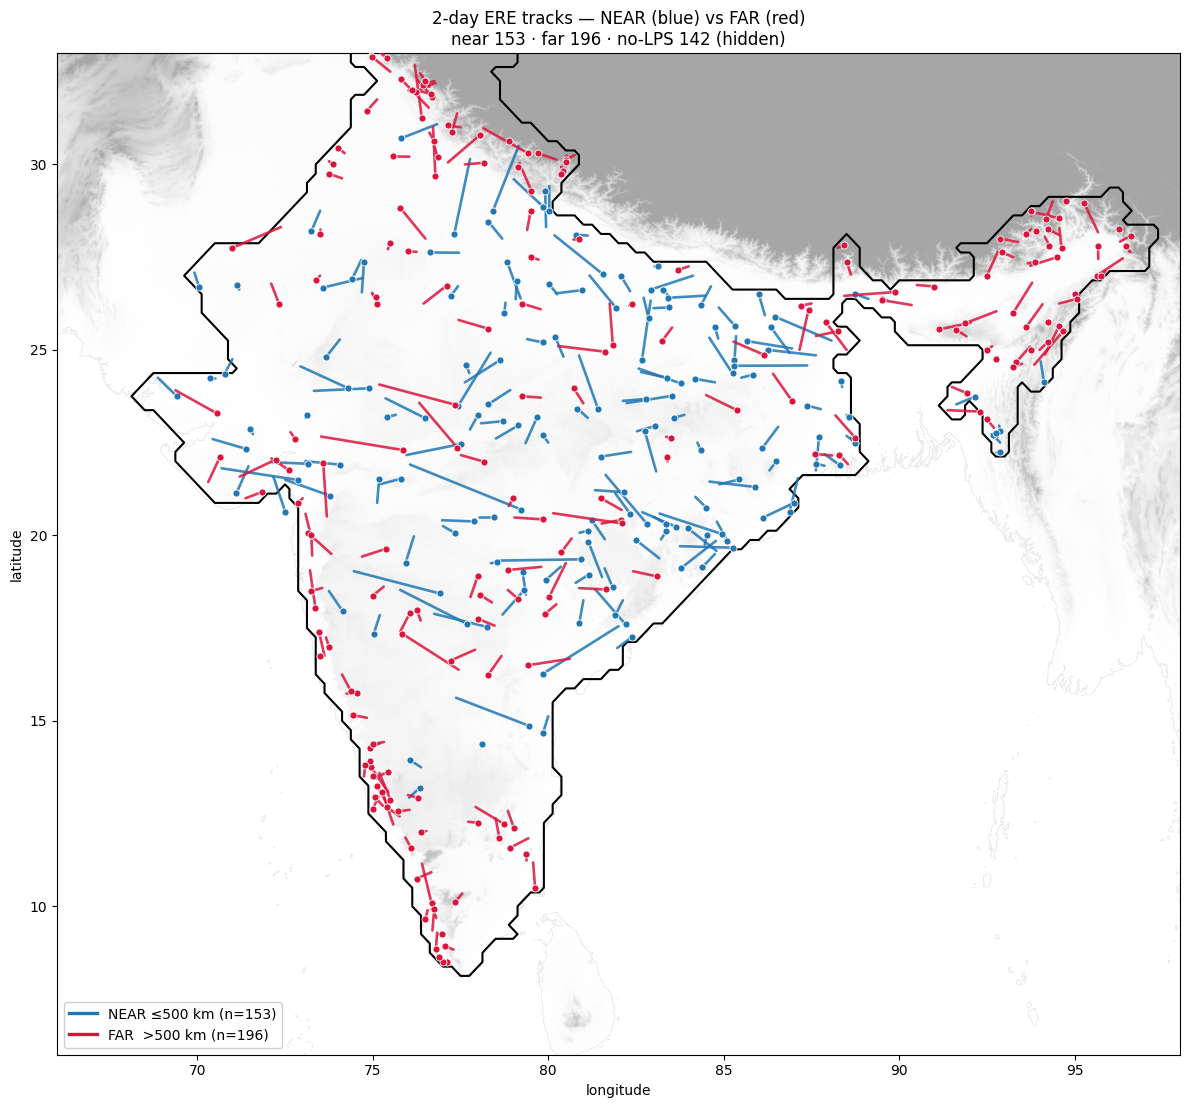

2-day: near 153 · far 196 · no-LPS 142


In [31]:
# ── Q3 · 2-day tracks only — NEAR (blue) vs FAR (red) clustering ──
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

SHOW_NOLPS = False

sel2   = track_class[track_class.duration == 2]
near2  = sel2.index[sel2.lps_class == 'near']
far2   = sel2.index[sel2.lps_class == 'far']
nol2   = sel2.index[sel2.lps_class == 'no_lps']

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(np.where(Z < 0, np.nan, Z), origin='lower',
          extent=[dem_lon[0], dem_lon[-1], dem_lat[0], dem_lat[-1]],
          cmap='Greys', vmin=0, vmax=3000, alpha=0.35, interpolation='bilinear', zorder=0)
LONg, LATg = np.meshgrid(lon, lat)
ax.contour(LONg, LATg, india_mask.astype(int), levels=[0.5], colors='k', lw=0.7, zorder=1)

def draw2(tns, col, z):
    for tn in tns:
        g = stats_lps[stats_lps.track_num == tn].sort_values('day_of_track')
        ax.plot(g.centroid_lon, g.centroid_lat, '-', color=col, lw=1.9,
                alpha=0.85, zorder=z, solid_capstyle='round')
        ax.scatter(g.centroid_lon.iloc[0], g.centroid_lat.iloc[0], s=26,
                   color=col, edgecolor='white', lw=0.6, zorder=z+1)   # genesis

if SHOW_NOLPS: draw2(nol2, '0.55', 2)
draw2(near2, 'tab:blue', 3)
draw2(far2,  'crimson',  4)

ax.set_xlim(66, 98); ax.set_ylim(6, 33); ax.set_aspect(1.057)
ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
handles = [Line2D([0],[0], color='tab:blue', lw=2.4, label=f'NEAR ≤500 km (n={len(near2)})'),
           Line2D([0],[0], color='crimson',  lw=2.4, label=f'FAR  >500 km (n={len(far2)})')]
if SHOW_NOLPS: handles.append(Line2D([0],[0], color='0.55', lw=2.4, label=f'no-LPS (n={len(nol2)})'))
ax.legend(handles=handles, loc='lower left', framealpha=0.95)
ax.set_title(f"2-day ERE tracks — NEAR (blue) vs FAR (red)\n"
             f"near {len(near2)} · far {len(far2)} · no-LPS {len(nol2)} "
             f"({'shown' if SHOW_NOLPS else 'hidden'})")
plt.tight_layout(); plt.show()
print(f"2-day: near {len(near2)} · far {len(far2)} · no-LPS {len(nol2)}")

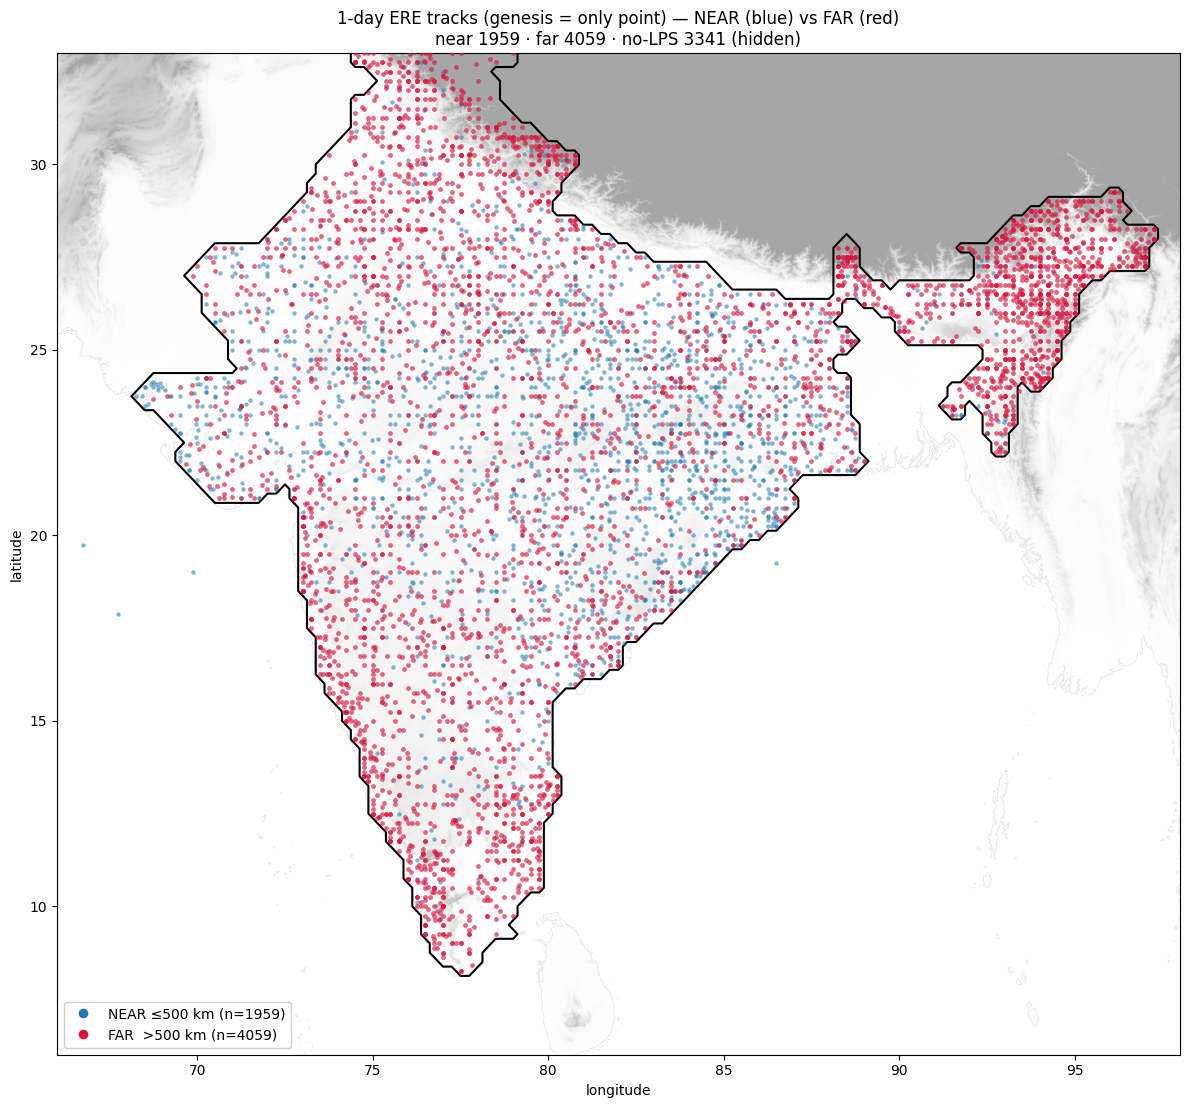

1-day: near 1959 · far 4059 · no-LPS 3341


In [32]:
# ── Q4 · 1-day tracks only — dots, FAR (red) vs NEAR (blue) ──
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

SHOW_NOLPS = False

sel1  = track_class[track_class.duration == 1]
near1 = set(sel1.index[sel1.lps_class == 'near'])
far1  = set(sel1.index[sel1.lps_class == 'far'])
nol1  = set(sel1.index[sel1.lps_class == 'no_lps'])

g_near = stats_lps[stats_lps.track_num.isin(near1)]
g_far  = stats_lps[stats_lps.track_num.isin(far1)]
g_nol  = stats_lps[stats_lps.track_num.isin(nol1)]

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(np.where(Z < 0, np.nan, Z), origin='lower',
          extent=[dem_lon[0], dem_lon[-1], dem_lat[0], dem_lat[-1]],
          cmap='Greys', vmin=0, vmax=3000, alpha=0.35, interpolation='bilinear', zorder=0)
LONg, LATg = np.meshgrid(lon, lat)
ax.contour(LONg, LATg, india_mask.astype(int), levels=[0.5], colors='k', lw=0.7, zorder=1)

if SHOW_NOLPS:
    ax.scatter(g_nol.centroid_lon, g_nol.centroid_lat, s=7, color='0.6', alpha=0.5, lw=0, zorder=2)
ax.scatter(g_near.centroid_lon, g_near.centroid_lat, s=10, color='tab:blue',
           alpha=0.55, lw=0, zorder=3)
ax.scatter(g_far.centroid_lon,  g_far.centroid_lat,  s=12, color='crimson',
           alpha=0.65, lw=0, zorder=4)

ax.set_xlim(66, 98); ax.set_ylim(6, 33); ax.set_aspect(1.057)
ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor='tab:blue',
                  markersize=8, label=f'NEAR ≤500 km (n={len(near1)})'),
           Line2D([0],[0], marker='o', color='w', markerfacecolor='crimson',
                  markersize=8, label=f'FAR  >500 km (n={len(far1)})')]
if SHOW_NOLPS:
    handles.append(Line2D([0],[0], marker='o', color='w', markerfacecolor='0.6',
                          markersize=7, label=f'no-LPS (n={len(nol1)})'))
ax.legend(handles=handles, loc='lower left', framealpha=0.95)
ax.set_title(f"1-day ERE tracks (genesis = only point) — NEAR (blue) vs FAR (red)\n"
             f"near {len(near1)} · far {len(far1)} · no-LPS {len(nol1)} "
             f"({'shown' if SHOW_NOLPS else 'hidden'})")
plt.tight_layout(); plt.show()
print(f"1-day: near {len(near1)} · far {len(far1)} · no-LPS {len(nol1)}")

In [33]:
# ── Q5 · do 1-day & 2-day FAR tracks sit on steeper terrain than NEAR? (mirror of the 3+day test) ──
import numpy as np, pandas as pd
from scipy.stats import mannwhitneyu

date_to_idx = {ts.strftime('%Y%m%d'): i for i, ts in enumerate(times_pd)}
land_slope  = slope_max_025[india_mask & np.isfinite(slope_max_025)]
SLOPE_THR   = float(np.percentile(land_slope, 75))
def cliffs(a, b): return 2*mannwhitneyu(a, b).statistic/(len(a)*len(b)) - 1

def footprint_terrain(tns):
    rows = []
    for r in stats_lps[stats_lps.track_num.isin(tns)].itertuples(index=False):
        t = date_to_idx.get(r.date)
        if t is None: continue
        m = (Label8[t] == int(r.day_lbl))
        if not m.any(): continue
        sl, ro = slope_max_025[m], rough_025[m]
        ok = np.isfinite(sl)
        if not ok.any(): continue
        rows.append(dict(tn=int(r.track_num),
                         slope=float(np.nanmax(sl[ok])),
                         rough=float(np.nanmean(ro[ok])),
                         frac_steep=float((sl[ok] >= SLOPE_THR).mean())))
    if not rows: return pd.DataFrame(columns=['slope','rough','frac_steep'])
    return pd.DataFrame(rows).groupby('tn')[['slope','rough','frac_steep']].mean()

for DUR in (1, 2):
    s = track_class[track_class.duration == DUR]
    Fp_ = footprint_terrain(s.index[s.lps_class == 'far'])
    Np_ = footprint_terrain(s.index[s.lps_class == 'near'])
    print(f"\n===== {DUR}-DAY · terrain under footprint · far {len(Fp_)} vs near {len(Np_)} tracks "
          f"(SLOPE_THR={SLOPE_THR:.0f} m/km) =====")
    print(f"{'metric':22s}{'FAR med':>10s}{'NEAR med':>10s}{'p(far>near)':>14s}{'Cliff δ':>9s}")
    for k, nm in [('slope','max slope m/km'), ('rough','roughness m'), ('frac_steep','frac steep')]:
        a, b = Fp_[k].dropna(), Np_[k].dropna()
        if len(a) < 3 or len(b) < 3:
            print(f"{nm:22s}{'—':>10s}{'—':>10s}{'(n too small)':>14s}"); continue
        p = mannwhitneyu(a, b, alternative='greater').pvalue
        print(f"{nm:22s}{a.median():>10.2f}{b.median():>10.2f}{p:>14.1e}{cliffs(a,b):>+9.2f}")
    print("compare to 3–7 day headline: slope δ≈+0.39, rough δ≈+0.46, frac_steep δ≈+0.45 (all p≤1e-4).")


===== 1-DAY · terrain under footprint · far 4052 vs near 1946 tracks (SLOPE_THR=98 m/km) =====
metric                   FAR med  NEAR med   p(far>near)  Cliff δ
max slope m/km             79.80     52.11       1.5e-38    +0.21
roughness m                51.92     34.15       4.3e-45    +0.22
frac steep                  0.00      0.00       4.1e-59    +0.23
compare to 3–7 day headline: slope δ≈+0.39, rough δ≈+0.46, frac_steep δ≈+0.45 (all p≤1e-4).

===== 2-DAY · terrain under footprint · far 196 vs near 153 tracks (SLOPE_THR=98 m/km) =====
metric                   FAR med  NEAR med   p(far>near)  Cliff δ
max slope m/km            196.31     94.11       6.4e-10    +0.38
roughness m                99.48     41.56       4.1e-10    +0.38
frac steep                  0.34      0.04       2.6e-10    +0.38
compare to 3–7 day headline: slope δ≈+0.39, rough δ≈+0.46, frac_steep δ≈+0.45 (all p≤1e-4).
